# **Seminar 7 - Генеративные нейросети, часть 2**
*Naumov Anton (Any0019)*

*To contact me in telegram: @any0019*

## 0. Подготовим данные и основные блоки модели (с прошлого семинара)

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as tr

import matplotlib.pyplot as plt
from matplotlib import style
style.use('fivethirtyeight')
%matplotlib inline

from tqdm.auto import tqdm, trange

import numpy as np

### 0.1 Данные

In [3]:
data_folder = "/home/jupyter/datasphere/project/datasets"

train_data = datasets.FashionMNIST(
    root=data_folder,
    train=True,
    download=True,
)

val_data = datasets.FashionMNIST(
    root=data_folder,
    train=False,
    download=True,
)

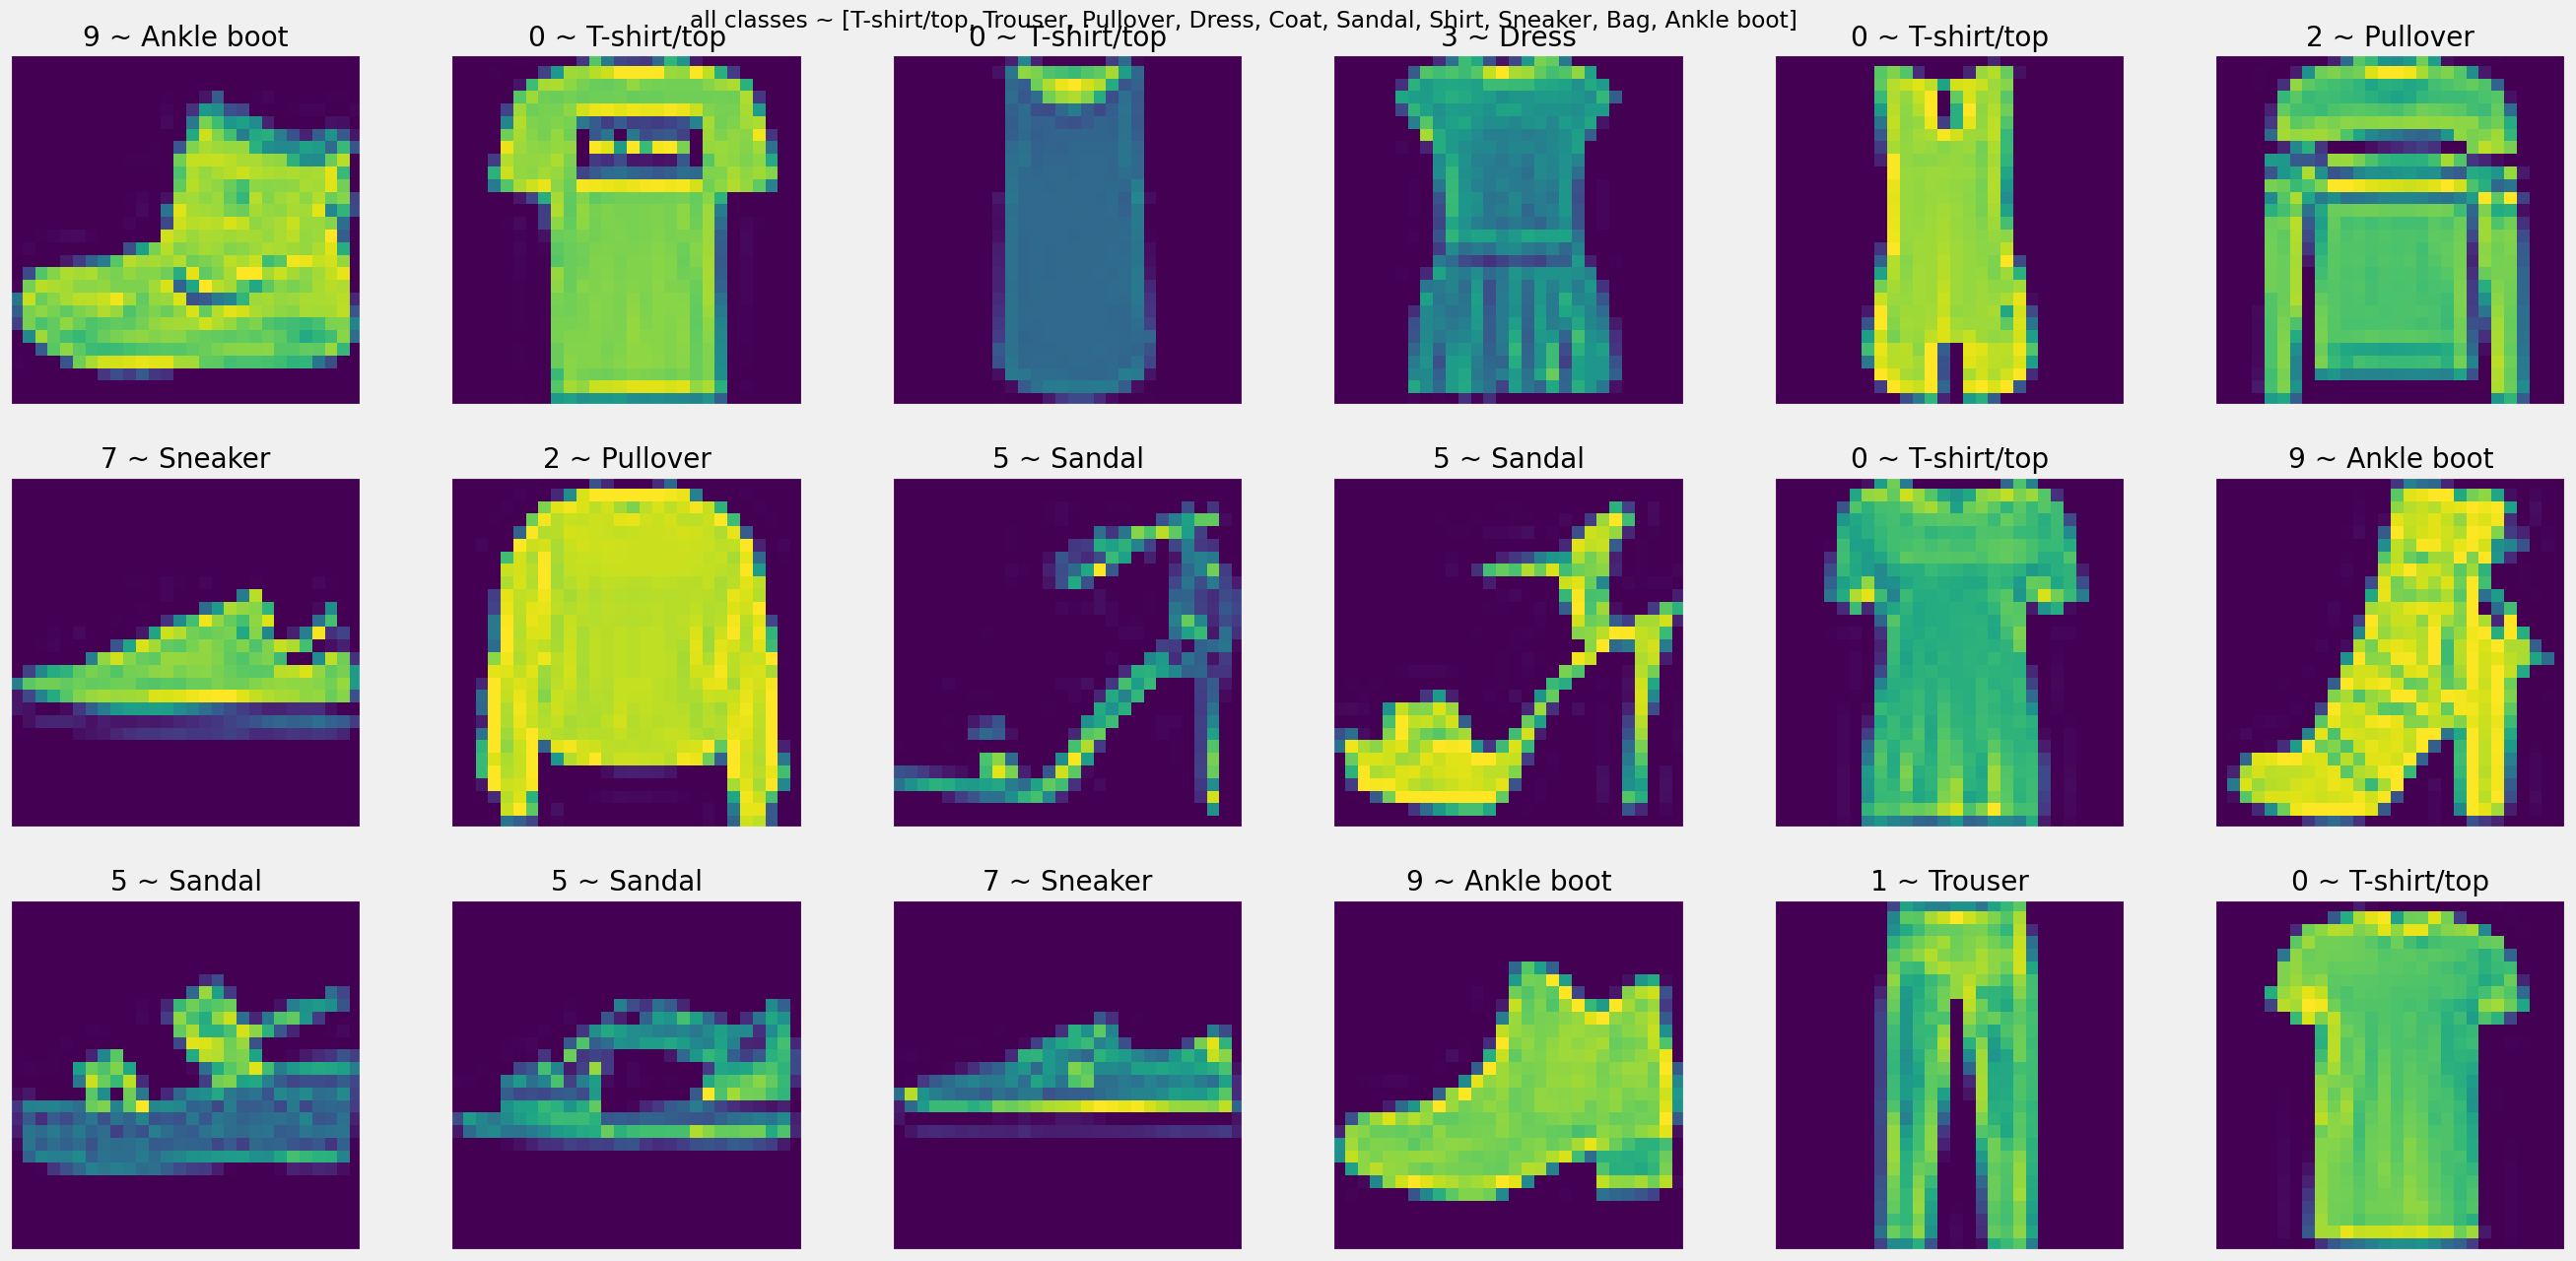

In [4]:
classes = train_data.classes

h = 3
w = 6
fig, ax = plt.subplots(h, w, figsize=(30, 15))

fig.suptitle(f"all classes ~ [{', '.join(classes)}]", y=0.85 + 0.02*h)
for i in range(h * w):
    plt.subplot(h, w, i+1)
    img, cl = train_data[i]
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.title(f"{cl} ~ {classes[cl]}")
plt.show()

In [5]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: /home/jupyter/datasphere/project/datasets
    Split: Train

In [6]:
val_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: /home/jupyter/datasphere/project/datasets
    Split: Test

In [8]:
train_data[0][0].size

(28, 28)

In [9]:
channel_mean, channel_std = 0, 0
for img, cl in tqdm(train_data):
    img = np.array(img) / 255.
    channel_mean += img.mean()
    channel_std += img.std()
channel_mean /= len(train_data)
channel_std /= len(train_data)

print(channel_mean, channel_std)

100%|██████████| 60000/60000 [00:09<00:00, 6320.21it/s]

0.2860405969887968 0.32024892543116534


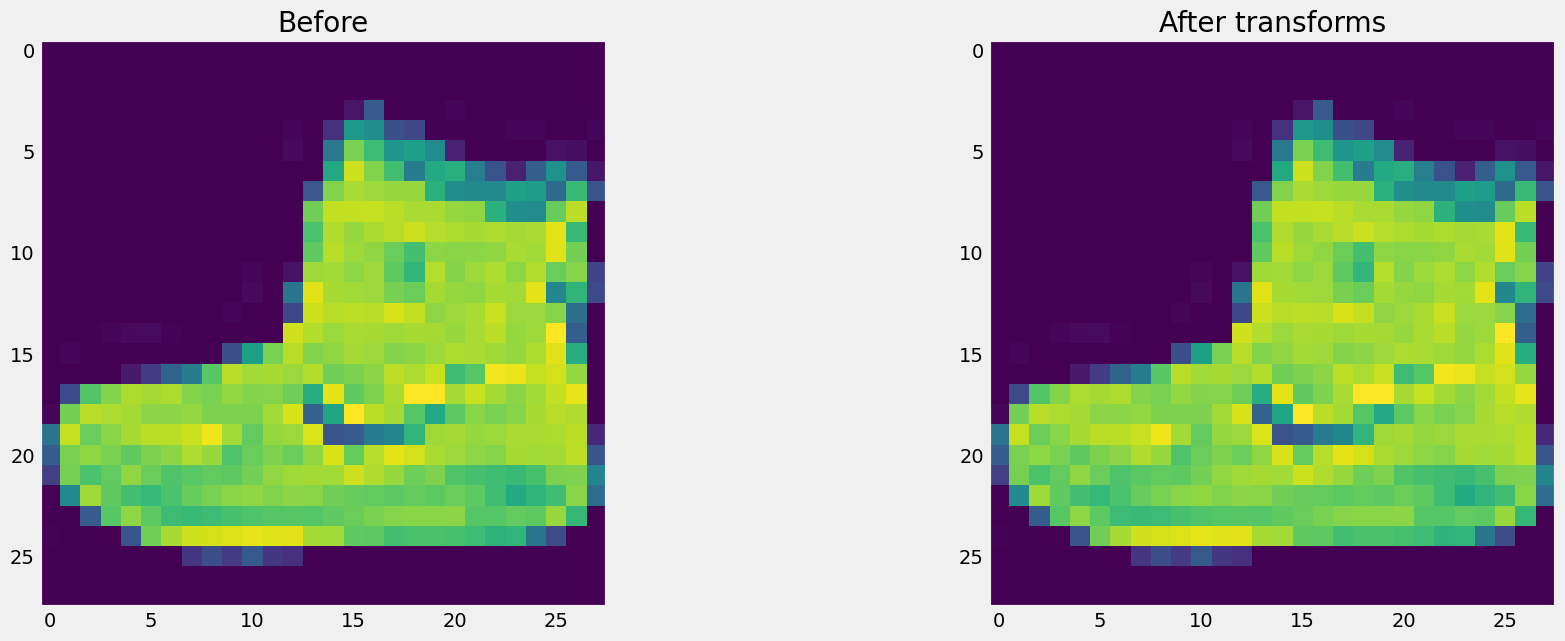

In [10]:
transforms = tr.Compose([
    tr.RandomHorizontalFlip(),
    tr.ToTensor(),
    # tr.Normalize(mean=channel_mean, std=channel_std),
])


def de_normalize(img, normalized=True):
    img = img.detach().cpu().numpy().transpose((1, 2, 0))
    if normalized:
        return img * channel_std + channel_mean
    else:
        return img


img_ind = 0

fig, ax = plt.subplots(1, 2, figsize=(20, 7))

plt.subplot(121)
plt.imshow(train_data[img_ind][0])
plt.grid()
plt.title("Before")

plt.subplot(122)
plt.imshow(de_normalize(transforms(train_data[img_ind][0])))
plt.grid()
plt.title("After transforms")

plt.show()

In [12]:
class ImageDataset(Dataset):
    def __init__(self, dataset, transforms):
        super(ImageDataset).__init__()
        self.dataset = dataset
        self.transforms = transforms

    def __getitem__(self, index):
        img, cl = self.dataset[index]
        return self.transforms(img), cl
    
    def __len__(self):
        return len(self.dataset)

train_ds = ImageDataset(train_data, transforms)
val_ds = ImageDataset(val_data, transforms)

batch_size = 5000

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

### 0.2 Residual block общего вида

In [13]:
from collections import OrderedDict
from functools import partial

class ResidualBlock(nn.Module):
    def __init__(self, c_in, c_out, kernel_size, n_layers, activation_class=nn.ReLU, dropout_p=0.3, reverse=False, do_scale=True, change_size=0):
        super(ResidualBlock, self).__init__()
        
        self.c_in = c_in
        self.c_out = c_out
        self.kernel_size = kernel_size
        self.n_layers = n_layers
        self.activation_class = activation_class
        self.dropout_p = dropout_p
        self.reverse = reverse
        self.do_scale = do_scale
        self.change_size = change_size
        
        if self.reverse:
            self.conv_class = nn.ConvTranspose2d
            self.scale_class = partial(
                nn.ConvTranspose2d,
                in_channels=self.c_out,
                out_channels=self.c_out,
                stride=2,
            )
            self.conv_name_prefix = "deconv"
            self.scale_name = "upscale"
            self.change_name = "add_size"
        else:
            self.conv_class = nn.Conv2d
            self.scale_class = nn.MaxPool2d
            self.conv_name_prefix = "conv"
            self.scale_name = "downscale"
            self.change_name = "sub_size"
        
        layers = [
            nn.Sequential(OrderedDict([
                (
                    self.conv_name_prefix,
                    self.conv_class(
                        in_channels = self.c_in if i == 0 else self.c_out,
                        out_channels = self.c_out,
                        kernel_size = self.kernel_size,
                        padding = (self.kernel_size - 1) // 2,
                        bias=False,
                    ),
                ),
                ("bnorm", nn.BatchNorm2d(self.c_out)),
                ("act", self.activation_class()),
                ("drop", nn.Dropout2d(self.dropout_p)),
            ])) for i in range(self.n_layers)
        ]
        
        self.layers = nn.Sequential(OrderedDict([(f"layer_{i}", layer) for i, layer in enumerate(layers)]))
        
        self.adapt_residual = nn.Identity() if self.c_in == self.c_out else self.conv_class(self.c_in, self.c_out, 1)
        
        scale = [
            (self.change_name, self.conv_class(self.c_out, self.c_out, self.change_size + 1) if self.change_size > 0 else nn.Identity()),
            (self.scale_name, self.scale_class(kernel_size=2) if self.do_scale else nn.Identity()),
        ]
        self.scale = nn.Sequential(OrderedDict(scale))
        
    
    def forward(self, x):
        return self.scale(self.layers(x) + self.adapt_residual(x))

In [14]:
encoder_res_block = ResidualBlock(
    c_in=2,
    c_out=4,
    kernel_size=3,
    n_layers=5,
    activation_class=nn.ReLU,
    dropout_p=0.3,
    reverse=False,
    do_scale=True,
    change_size=0,
)
print(encoder_res_block)

tmp_in = torch.rand(1, 2, 10, 10)
tmp_out = encoder_res_block(tmp_in)

print(
    "---------",
    f"input shape: {list(tmp_in.shape)}",
    f"output shape: {list(tmp_out.shape)}",
    sep="\n",
)

ResidualBlock(
  (layers): Sequential(
    (layer_0): Sequential(
      (conv): Conv2d(2, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
      (drop): Dropout2d(p=0.3, inplace=False)
    )
    (layer_1): Sequential(
      (conv): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
      (drop): Dropout2d(p=0.3, inplace=False)
    )
    (layer_2): Sequential(
      (conv): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
      (drop): Dropout2d(p=0.3, inplace=False)
    )
    (layer_3): Sequential(
      (conv): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fa

In [15]:
decoder_res_block = ResidualBlock(
    c_in=2,
    c_out=4,
    kernel_size=3,
    n_layers=5,
    activation_class=nn.Tanh,
    dropout_p=0.1,
    reverse=True,
    do_scale=True,
    change_size=0,
)
print(decoder_res_block)

tmp_in = torch.rand(1, 2, 10, 10)
tmp_out = decoder_res_block(tmp_in)

print(
    "---------",
    f"input shape: {list(tmp_in.shape)}",
    f"output shape: {list(tmp_out.shape)}",
    sep="\n",
)

ResidualBlock(
  (layers): Sequential(
    (layer_0): Sequential(
      (deconv): ConvTranspose2d(2, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): Tanh()
      (drop): Dropout2d(p=0.1, inplace=False)
    )
    (layer_1): Sequential(
      (deconv): ConvTranspose2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): Tanh()
      (drop): Dropout2d(p=0.1, inplace=False)
    )
    (layer_2): Sequential(
      (deconv): ConvTranspose2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): Tanh()
      (drop): Dropout2d(p=0.1, inplace=False)
    )
    (layer_3): Sequential(
      (deconv): ConvTranspose2d(4, 4, kernel_size=(3

In [17]:
decoder_res_block = ResidualBlock(
    c_in=2,
    c_out=4,
    kernel_size=3,
    n_layers=5,
    activation_class=nn.Sigmoid,
    dropout_p=0.,
    reverse=True,
    do_scale=False,
    change_size=4,
)
print(decoder_res_block)

tmp_in = torch.rand(1, 2, 10, 10)
tmp_out = decoder_res_block(tmp_in)

print(
    "---------",
    f"input shape: {list(tmp_in.shape)}",
    f"output shape: {list(tmp_out.shape)}",
    sep="\n",
)

ResidualBlock(
  (layers): Sequential(
    (layer_0): Sequential(
      (deconv): ConvTranspose2d(2, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): Sigmoid()
      (drop): Dropout2d(p=0.0, inplace=False)
    )
    (layer_1): Sequential(
      (deconv): ConvTranspose2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): Sigmoid()
      (drop): Dropout2d(p=0.0, inplace=False)
    )
    (layer_2): Sequential(
      (deconv): ConvTranspose2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): Sigmoid()
      (drop): Dropout2d(p=0.0, inplace=False)
    )
    (layer_3): Sequential(
      (deconv): ConvTranspose2d(4, 4, kerne

### 0.3 Энкодер (+ conditional)

In [18]:
class Encoder(nn.Module):
    def __init__(
        self,
        num_blocks,
        block_sizes,
        hidden_sizes,
        kernel_sizes,
        activation_classes,
        use_scales,
        change_sizes,
        dropout_ps,
        fc_size=0,
        # Новый параметр - сколько различных классов всего (для CVAE, CGAN, ... на классификационном таргете)
        cond_n_class=0,
        # Новый параметр - размер эмбеддинга для condition
        cond_emb_size=None,
    ):
        super(Encoder, self).__init__()
        
        def fill_list(val, size):
            if isinstance(val, list):
                assert len(val) == size
                return val
            return [val for _ in range(size)]
        
        self.num_blocks = num_blocks
        self.block_sizes = fill_list(block_sizes, self.num_blocks)
        self.hidden_sizes = [1] + fill_list(hidden_sizes, self.num_blocks)
        self.kernel_sizes = fill_list(kernel_sizes, self.num_blocks)
        self.activation_classes = fill_list(activation_classes, self.num_blocks)
        self.use_scales = fill_list(use_scales, self.num_blocks)
        self.change_sizes = fill_list(change_sizes, self.num_blocks)
        self.dropout_ps = fill_list(dropout_ps, self.num_blocks)
        self.fc_size = fc_size
        # Записали в self
        self.cond_n_class = cond_n_class
        self.cond_emb_size = cond_emb_size
        
        # Если параметр передан, то создаём lookup-табличку с эмбеддингами для классов
        if self.cond_n_class > 0:
            self.cond_adapt = nn.Embedding(
                num_embeddings=self.cond_n_class,
                embedding_dim=self.cond_emb_size,
            )
            # будем добавлять как дополнительные каналы
            self.hidden_sizes[0] += self.cond_emb_size
        else:
            self.cond_adapt = nn.Identity()
            
        
        self.residual_blocks = nn.Sequential(OrderedDict([
            (
                f"residual_{i}",
                ResidualBlock(
                    c_in=self.hidden_sizes[i],
                    c_out=self.hidden_sizes[i+1],
                    kernel_size=self.kernel_sizes[i],
                    n_layers=self.block_sizes[i],
                    activation_class=self.activation_classes[i],
                    dropout_p=self.dropout_ps[i],
                    reverse=False,
                    do_scale=self.use_scales[i],
                    change_size=self.change_sizes[i],
                ),
            ) for i in range(self.num_blocks)
        ]))
        
        self.global_pool = nn.AdaptiveAvgPool2d(output_size=(1, 1)) if self.fc_size > 0 else nn.Identity()
        self.fc = nn.Linear(self.hidden_sizes[-1], self.fc_size) if self.fc_size > 0 else nn.Identity()
    
    def forward(self, x, c=None):
        if c is not None:
            assert self.cond_n_class > 0, "Unconditional model used with condition"
            c = self.cond_adapt(c)  # bs x c_emb
            x = torch.cat(  # bs x (1 + c_emb) x h x w
                (
                    x,
                    c[:, :, None, None].repeat(1, 1, x.shape[2], x.shape[3]),
                ),
                dim=1,
            )
        out = self.residual_blocks(x)
        out = self.global_pool(out).squeeze(-1).squeeze(-1)
        return self.fc(out)

In [19]:
encoder = Encoder(
    num_blocks=2,
    block_sizes=[2, 3],
    hidden_sizes=[4, 8],
    kernel_sizes=3,
    activation_classes=nn.ReLU,
    use_scales=[True, False],
    change_sizes=[0, 1],
    dropout_ps=0.1,
    fc_size=7,
)

print(encoder)

tmp_in = torch.rand(2, 1, 10, 10)
tmp_out = encoder(tmp_in)

print(
    "---------",
    f"input shape: {list(tmp_in.shape)}",
    f"output shape: {list(tmp_out.shape)}",
    sep="\n",
)

Encoder(
  (cond_adapt): Identity()
  (residual_blocks): Sequential(
    (residual_0): ResidualBlock(
      (layers): Sequential(
        (layer_0): Sequential(
          (conv): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (drop): Dropout2d(p=0.1, inplace=False)
        )
        (layer_1): Sequential(
          (conv): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (drop): Dropout2d(p=0.1, inplace=False)
        )
      )
      (adapt_residual): Conv2d(1, 4, kernel_size=(1, 1), stride=(1, 1))
      (scale): Sequential(
        (sub_size): Identity()
        (downscale): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (res

In [20]:
# Проверка с condition
encoder = Encoder(
    num_blocks=2,
    block_sizes=[2, 3],
    hidden_sizes=[4, 8],
    kernel_sizes=3,
    activation_classes=nn.ReLU,
    use_scales=[True, False],
    change_sizes=[0, 1],
    dropout_ps=0.1,
    fc_size=7,
    # Новые параметры
    cond_n_class=5,
    cond_emb_size=20,
)

print(encoder)

tmp_in = torch.rand(2, 1, 10, 10)
tmp_c = torch.randint(5, size=(2,))
tmp_out = encoder(tmp_in, tmp_c)

print(
    "---------",
    f"input shape: {list(tmp_in.shape)}",
    f"output shape: {list(tmp_out.shape)}",
    sep="\n",
)

Encoder(
  (cond_adapt): Embedding(5, 20)
  (residual_blocks): Sequential(
    (residual_0): ResidualBlock(
      (layers): Sequential(
        (layer_0): Sequential(
          (conv): Conv2d(21, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (drop): Dropout2d(p=0.1, inplace=False)
        )
        (layer_1): Sequential(
          (conv): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (drop): Dropout2d(p=0.1, inplace=False)
        )
      )
      (adapt_residual): Conv2d(21, 4, kernel_size=(1, 1), stride=(1, 1))
      (scale): Sequential(
        (sub_size): Identity()
        (downscale): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )


### 0.4 Декодер (+ conditional)

In [21]:
class Decoder(nn.Module):
    def __init__(
        self,
        num_blocks,
        block_sizes,
        hidden_sizes,
        kernel_sizes,
        activation_classes,
        use_scales,
        change_sizes,
        dropout_ps,
        # Новый параметр - сколько различных классов всего (для CVAE, CGAN, ... на классификационном таргете)
        cond_n_class=0,
        # Новый параметр - размер эмбеддинга для condition
        cond_emb_size=None,
    ):
        super(Decoder, self).__init__()
        
        def fill_list(val, size):
            if isinstance(val, list):
                assert len(val) == size
                return val
            return [val for _ in range(size)]
        
        self.num_blocks = num_blocks
        self.block_sizes = fill_list(block_sizes, self.num_blocks)
        self.hidden_sizes = fill_list(hidden_sizes, self.num_blocks + 1)
        self.kernel_sizes = fill_list(kernel_sizes, self.num_blocks)
        self.activation_classes = fill_list(activation_classes, self.num_blocks)
        self.use_scales = fill_list(use_scales, self.num_blocks)
        self.change_sizes = fill_list(change_sizes, self.num_blocks)
        self.dropout_ps = fill_list(dropout_ps, self.num_blocks)
        # Записали в self
        self.cond_n_class = cond_n_class
        self.cond_emb_size = cond_emb_size
        
        # Если параметр передан, то создаём lookup-табличку с эмбеддингами для классов
        if self.cond_n_class > 0:
            self.cond_adapt = nn.Embedding(
                num_embeddings=self.cond_n_class,
                embedding_dim=self.cond_emb_size,
            )
            self.hidden_sizes[0] += self.cond_emb_size
        else:
            self.cond_adapt = nn.Identity()
    
        self.residual_blocks = nn.Sequential(OrderedDict([
            (
                f"residual_{i}",
                ResidualBlock(
                    c_in=self.hidden_sizes[i],
                    c_out=self.hidden_sizes[i+1],
                    kernel_size=self.kernel_sizes[i],
                    n_layers=self.block_sizes[i],
                    activation_class=self.activation_classes[i],
                    dropout_p=self.dropout_ps[i],
                    reverse=True,
                    do_scale=self.use_scales[i],
                    change_size=self.change_sizes[i],
                ),
            ) for i in range(self.num_blocks)
        ]))
        
    def forward(self, x, c=None):
        if c is not None:
            assert self.cond_n_class > 0, "Unconditional model used with condition"
            c = self.cond_adapt(c)  # bs x c_emb
            x = torch.cat(  # bs x (hid + c_emb) x h x w
                (
                    x,
                    c[:, :, None, None].repeat(1, 1, x.shape[2], x.shape[3]),
                ),
                dim=1,
            )
        return self.residual_blocks(x)

In [46]:
decoder = Decoder(
    num_blocks=2,
    block_sizes=[2, 3],
    hidden_sizes=[1, 4, 8],
    kernel_sizes=3,
    activation_classes=nn.ReLU,
    use_scales=[True, False],
    change_sizes=[0, 1],
    dropout_ps=0.1,
)

print(decoder)

tmp_in = torch.rand(2, 1, 10, 10)
tmp_out = decoder(tmp_in)

print(
    "---------",
    f"input shape: {list(tmp_in.shape)}",
    f"output shape: {list(tmp_out.shape)}",
    sep="\n",
)

Decoder(
  (cond_adapt): Identity()
  (residual_blocks): Sequential(
    (residual_0): ResidualBlock(
      (layers): Sequential(
        (layer_0): Sequential(
          (deconv): ConvTranspose2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (drop): Dropout2d(p=0.1, inplace=False)
        )
        (layer_1): Sequential(
          (deconv): ConvTranspose2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (drop): Dropout2d(p=0.1, inplace=False)
        )
      )
      (adapt_residual): ConvTranspose2d(1, 4, kernel_size=(1, 1), stride=(1, 1))
      (scale): Sequential(
        (add_size): Identity()
        (upscale): ConvTranspose2d(4, 4, kernel_size=(2, 2), stride=(2, 2))
      )
   

In [47]:
# Проверка с condition
decoder = Decoder(
    num_blocks=2,
    block_sizes=[2, 3],
    hidden_sizes=[1, 4, 8],
    kernel_sizes=3,
    activation_classes=nn.ReLU,
    use_scales=[True, False],
    change_sizes=[0, 1],
    dropout_ps=0.1,
    # Новые параметры
    cond_n_class=5,
    cond_emb_size=100,
)

print(decoder)

tmp_in = torch.rand(2, 1, 10, 10)
tmp_c = torch.randint(5, size=(2,))
tmp_out = decoder(tmp_in, tmp_c)

print(
    "---------",
    f"input shape: {list(tmp_in.shape)}",
    f"output shape: {list(tmp_out.shape)}",
    sep="\n",
)

Decoder(
  (cond_adapt): Embedding(5, 100)
  (residual_blocks): Sequential(
    (residual_0): ResidualBlock(
      (layers): Sequential(
        (layer_0): Sequential(
          (deconv): ConvTranspose2d(101, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (drop): Dropout2d(p=0.1, inplace=False)
        )
        (layer_1): Sequential(
          (deconv): ConvTranspose2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (drop): Dropout2d(p=0.1, inplace=False)
        )
      )
      (adapt_residual): ConvTranspose2d(101, 4, kernel_size=(1, 1), stride=(1, 1))
      (scale): Sequential(
        (add_size): Identity()
        (upscale): ConvTranspose2d(4, 4, kernel_size=(2, 2), stride=(2, 2))


## 1. Conditional VAE

### 1.1 CVAE class

In [53]:
class CondVAE(nn.Module):
    def __init__(self, hid_size, encoder_params, decoder_params):
        super(CondVAE, self).__init__()
        
        self.hid_size = hid_size
        self.encoder_params = encoder_params
        self.decoder_params = decoder_params

        self.encoder = Encoder(
            **encoder_params,
        )
        
        self.decoder = Decoder(
            **decoder_params,
        )
        
    def forward(self, x, c=None):  # bs x 1 x 28 x 28
        z_stat = self.encoder(x, c)  # bs x (hid_size * 2)
        
        bs = x.shape[0]
        hid_size = z_stat.shape[-1] // 2
        assert self.hid_size * 2 == z_stat.shape[-1], "hidden size mismatch"
        mu = z_stat[:, :hid_size]
        logvar = z_stat[:, hid_size:]
        
        # reparametrization trick  # bs x 16
        z = torch.randn(x.shape[0], hid_size).to(x.device) * torch.exp(logvar / 2.) + mu
        z_side = torch.sqrt(torch.tensor(z.shape[-1])).int()
        z = z.reshape(bs, 1, z_side, z_side)
        
        x_rec = self.decoder(z, c)
        
        return x_rec, (mu, logvar)

In [54]:
hid_size = 16

# 1x28x28 --> 4x14x14 --> 8x7x7 --> 16x3x3 --> 32x3x3 --> 32 --> hid_size * 2
# hid_size --> 1x4x4 --> 32x4x4 --> 16x12x12 --> 8x28x28 --> 1x28x28

cvae = CondVAE(
        hid_size = hid_size,
        encoder_params = dict(
            num_blocks=4,
            block_sizes=2,
            hidden_sizes=[4, 8, 16, 32],
            kernel_sizes=3,
            activation_classes=nn.ReLU,
            use_scales=[True, True, True, False],
            change_sizes=[0, 0, 1, 0],
            dropout_ps=[0, 0, 0.1, 0.2],
            fc_size=hid_size * 2,
            # Новые параметры
            cond_n_class=10,
            cond_emb_size=10,
        ),
        decoder_params = dict(
            num_blocks=4,
            block_sizes=2,
            hidden_sizes=[1, 32, 16, 8, 1],
            kernel_sizes=3,
            activation_classes=nn.ReLU,
            use_scales=[False, True, True, False],
            change_sizes=[0, 2, 2, 0],
            dropout_ps=[0.2, 0.1, 0, 0],
            # Новые параметры
            cond_n_class=10,
            cond_emb_size=10,
        ),
)

print(cvae)

tmp_in = torch.rand(2, 1, 28, 28)
tmp_c = torch.randint(10, size=(2,))
tmp_out, tmp_stat = cvae(tmp_in, tmp_c)

print(
    "---------",
    f"input shape: {list(tmp_in.shape)}",
    f"output shape: {list(tmp_out.shape)}",
    sep="\n",
)

CondVAE(
  (encoder): Encoder(
    (cond_adapt): Embedding(10, 10)
    (residual_blocks): Sequential(
      (residual_0): ResidualBlock(
        (layers): Sequential(
          (layer_0): Sequential(
            (conv): Conv2d(11, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): ReLU()
            (drop): Dropout2d(p=0, inplace=False)
          )
          (layer_1): Sequential(
            (conv): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): ReLU()
            (drop): Dropout2d(p=0, inplace=False)
          )
        )
        (adapt_residual): Conv2d(11, 4, kernel_size=(1, 1), stride=(1, 1))
        (scale): Sequential(
          (sub_size): Identity()
          (downscale): MaxPool2d(kernel_size=2, str

In [55]:
from collections import defaultdict
from termcolor import colored


def beautiful_int(i):
    i = str(i)
    return ".".join(reversed([i[max(j, 0):j+3] for j in range(len(i) - 3, -3, -3)]))


# Counting how many parameters does our model have
def model_num_params(model, verbose_all=True, verbose_only_learnable=False):
    sum_params = 0
    sum_learnable_params = 0
    submodules = defaultdict(lambda : [0, 0])
    for name, param in model.named_parameters():
        num_params = param.numel()
        if verbose_all or (verbose_only_learnable and param.requires_grad):
            print(
                colored(
                    '{: <65} ~  {: <9} params ~ grad: {}'.format(
                        name,
                        beautiful_int(num_params),
                        param.requires_grad,
                    ),
                    {True: "green", False: "red"}[param.requires_grad],
                )
            )
        sum_params += num_params
        sm = name.split(".")[0]
        submodules[sm][0] += num_params
        if param.requires_grad:
            sum_learnable_params += num_params
            submodules[sm][1] += num_params
    print(
        f'\nIn total:\n  - {beautiful_int(sum_params)} params\n  - {beautiful_int(sum_learnable_params)} learnable params'
    )
    
    for sm, v in submodules.items():
        print(
            f"\n . {sm}:\n .   - {beautiful_int(submodules[sm][0])} params\n .   - {beautiful_int(submodules[sm][1])} learnable params"
        )
    return sum_params, sum_learnable_params

sum_params, sum_learnable_params = model_num_params(cvae)

encoder.cond_adapt.weight                                         ~  100       params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_0.conv.weight     ~  396       params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_0.bnorm.weight    ~  4         params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_0.bnorm.bias      ~  4         params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_1.conv.weight     ~  144       params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_1.bnorm.weight    ~  4         params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_1.bnorm.bias      ~  4         params ~ grad: True
encoder.residual_blocks.residual_0.adapt_residual.weight          ~  44        params ~ grad: True
encoder.residual_blocks.residual_0.adapt_residual.bias            ~  4         params ~ grad: True
encoder.residual_blocks.residual_1.layers.layer_0.conv.weight     ~  288       params ~ grad: True
encoder.re

### 1.2 VAE Loss

In [56]:
def vae_loss(x_rec, x, mu, logvar, alpha=0.5, show_log=False):
    x_rec = F.sigmoid(x_rec)
    
    reconstruct_loss = ((x_rec - x)**2).sum(-1).sqrt().mean()
    kl_loss = - 0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(-1).mean()
    if show_log:
        print('KL = {}, MSE = {}'.format(kl_loss, reconstruct_loss))
    return alpha * reconstruct_loss + (1 - alpha) * kl_loss

In [57]:
vae_loss(tmp_out, tmp_in, *tmp_stat, 0.9, True)

KL = 1.229790449142456, MSE = 1.773123025894165


tensor(1.7188, grad_fn=<AddBackward0>)

### 1.3 Model creation

In [34]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

def create_model_and_optimizer(model_class, model_params, lr=1e-3, beta1=0.9, beta2=0.999, device=device):
    model = model_class(**model_params).float()
    model = model.to(device)
    
    optimizer = torch.optim.Adam([param for param in model.parameters() if param.requires_grad], lr, [beta1, beta2])
    return model, optimizer

hid_size = 16

model, optimizer = create_model_and_optimizer(
    model_class = CondVAE,
    model_params = dict(
        hid_size = hid_size,
        encoder_params = dict(
            num_blocks=4,
            block_sizes=[3, 3, 3, 3],
            hidden_sizes=[8, 16, 32, 64],
            kernel_sizes=3,
            activation_classes=nn.ReLU,
            use_scales=[True, True, True, True],
            change_sizes=[0, 0, 1, 1],
            dropout_ps=[0., 0., 0.125, 0.25],
            fc_size=hid_size * 2,
            # Новые параметры
            cond_n_class=10,
            cond_emb_size=10,
        ),
        decoder_params = dict(
            num_blocks=4,
            block_sizes=[3, 3, 3, 3],
            hidden_sizes=[hid_size, 64, 32, 16, 1],
            kernel_sizes=3,
            activation_classes=[nn.ReLU, nn.ReLU, nn.ReLU, nn.Sigmoid],
            use_scales=[True, True, True, False],
            change_sizes=[2, 1, 0, 0],
            dropout_ps=0.,
            # Новые параметры
            cond_n_class=10,
            cond_emb_size=16,
        ),
    ),
    lr = 1e-3,
    device = device,
)

### 1.4 Train loop VAE

In [35]:
from collections import defaultdict

def train_vae(model, opt, loader, criterion):
    model.train()
    losses_tr = []
    for imgs, classes in tqdm(loader):
        imgs = imgs.to(device)
        classes = classes.to(device)
        
        optimizer.zero_grad()
        imgs_rec, (mu, logvar) = model(imgs, classes)
        loss = criterion(imgs_rec, imgs, mu, logvar)
        
        loss.backward()
        optimizer.step()
        losses_tr.append(loss.item())
    
    return model, optimizer, np.mean(losses_tr)


def val_vae(model, loader, criterion):
    model.eval()
    losses_val = []
    with torch.no_grad():
        for imgs, classes in tqdm(loader):
            imgs = imgs.to(device)
            classes = classes.to(device)
            
            imgs_rec, (mu, logvar) = model(imgs, classes)
            loss = criterion(imgs_rec, imgs, mu, logvar)

            losses_val.append(loss.item())
    
    return np.mean(losses_val)

In [61]:
from IPython.display import clear_output
import warnings
import os
import copy

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

results = []

def draw_imgs_vae(model, h, w, num_classes=0, target_classes=None):
    global results
    model.eval()
    fig, ax = plt.subplots(h, w, figsize=(4*w, 5*h))
    with torch.no_grad():
        assert target_classes is None or num_classes == 0
        c = None
        if num_classes > 0:
            c = torch.randint(num_classes, size=(h*w,)).to(device)
        if target_classes is not None:
            assert target_classes.shape[0] == h * w
            c = target_classes.to(device)
        
        pred = model.decoder(torch.randn(h * w, 1, 4, 4).to(device), c)
        pred = F.sigmoid(pred)
        to_draw = [de_normalize(pred[ind]) for ind in range(h * w)]
        results.append((copy.deepcopy(to_draw), c))
        
        for hh in range(h):
            for ww in range(w):
                ind = hh * w + ww
                plt.subplot(h, w, ind + 1)
                if c is not None:
                    plt.title(f"#{c[ind]} - {classes[c[ind]]}")
                plt.imshow(to_draw[ind])
                plt.grid()
    plt.show()

    
def get_model_name(chkp_folder, model_name=None):
    # Выбираем имя чекпоинта для сохранения
    if model_name is None:
        if os.path.exists(chkp_folder):
            num_starts = len(os.listdir(chkp_folder)) + 1
        else:
            num_starts = 1
        model_name = f'model#{num_starts}'
    else:
        if "#" not in model_name:
            model_name += "#0"
    changed = False
    while os.path.exists(os.path.join(chkp_folder, model_name + '.pt')):
        model_name, ind = model_name.split("#")
        model_name += f"#{int(ind) + 1}"
        changed=True
    if changed:
        warnings.warn(f"Selected model_name was used already! To avoid possible overwrite - model_name changed to {model_name}")
    return model_name
    

def learning_loop_vae(
    model,
    optimizer,
    train_loader,
    val_loader,
    criterion,
    scheduler=None,
    min_lr=None,
    epochs=10,
    val_every=1,
    draw_every=1,
    separate_show=False,
    model_name=None,
    chkp_folder="./chkps",
    num_classes=0,
    losses=None,
):
    model_name = get_model_name(chkp_folder, model_name)
    
    if losses is None:
        losses = {'train': [], 'val': []}
    lrs = []
    best_val_loss = np.Inf

    for epoch in range(1, epochs+1):
        print(f'#{epoch}/{epochs}:')

        lrs.append(get_lr(optimizer))
        
        model, optimizer, loss = train_vae(model, optimizer, train_loader, criterion)
        losses['train'].append(loss)

        if not (epoch % val_every):
            loss = val_vae(model, val_loader, criterion)
            losses['val'].append(loss)
            
            # Сохраняем лучшую по валидации модель
            if loss < best_val_loss:
                if not os.path.exists(chkp_folder):
                    os.makedirs(chkp_folder)
                torch.save(
                    {
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'scheduler_state_dict': scheduler.state_dict(),
                        'losses': losses,
                    },
                    os.path.join(chkp_folder, model_name + '.pt'),
                )
                best_val_loss = loss
            
            if scheduler:
                try:
                    scheduler.step()
                except:
                    scheduler.step(loss)

        if not (epoch % draw_every):
            clear_output(True)
            ww = 3 if separate_show else 2
                
            fig, ax = plt.subplots(1, ww, figsize=(20, 10))
            fig.suptitle(f'#{epoch}/{epochs}:')

            plt.subplot(1, ww, 1)
            plt.plot(losses['train'], 'r.-', label='train')
            if separate_show:
                plt.title('loss on train')
                plt.legend()
            # plt.grid()

            if separate_show:
                plt.subplot(1, ww, 2)
                plt.title('loss on validation')
                # plt.grid()
            else:
                plt.title('losses')
            plt.plot(losses['val'], 'g.-', label='val')
            plt.legend()
            
            plt.subplot(1, ww, ww)
            plt.title('learning rate')
            plt.plot(lrs, 'g.-', label='lr')
            plt.legend()
            # plt.grid()
            
            plt.show()
            
            draw_imgs_vae(model, 2, 5, num_classes=num_classes)
                
        
        if min_lr and get_lr(optimizer) <= min_lr:
            print(f'Learning process ended with early stop after epoch {epoch}')
            break
    
    return model, optimizer, losses

### 1.5 Training CVAE

In [79]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

hid_size = 16
enc_cond_emb_size = 5
dec_cond_emb_size = 5
cond_n_class = len(classes)

results = []

model, optimizer = create_model_and_optimizer(
    model_class = CondVAE,
    model_params = dict(
        hid_size = hid_size,
        encoder_params = dict(
            num_blocks=4,
            block_sizes=2,
            hidden_sizes=[4, 8, 16, 32],
            kernel_sizes=3,
            activation_classes=nn.ReLU,
            use_scales=[True, True, True, False],
            change_sizes=[0, 0, 1, 0],
            dropout_ps=[0, 0, 0.1, 0.2],
            fc_size=hid_size * 2,
            # Новые параметры
            cond_n_class=cond_n_class,
            cond_emb_size=enc_cond_emb_size,
        ),
        decoder_params = dict(
            num_blocks=4,
            block_sizes=2,
            hidden_sizes=[1, 32, 16, 8, 1],
            kernel_sizes=3,
            activation_classes=nn.ReLU,
            use_scales=[False, True, True, False],
            change_sizes=[0, 2, 2, 0],
            dropout_ps=[0.2, 0.1, 0, 0],
            # Новые параметры
            cond_n_class=cond_n_class,
            cond_emb_size=dec_cond_emb_size,
        ),
    ),
    lr = 1e-3,
    device = device,
)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.25, patience=4, threshold=0.001, verbose=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-4)

criterion = partial(vae_loss, alpha=0.999, show_log=False)

sum_params, sum_learnable_params = model_num_params(model)

encoder.cond_adapt.weight                                         ~  50        params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_0.conv.weight     ~  216       params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_0.bnorm.weight    ~  4         params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_0.bnorm.bias      ~  4         params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_1.conv.weight     ~  144       params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_1.bnorm.weight    ~  4         params ~ grad: True
encoder.residual_blocks.residual_0.layers.layer_1.bnorm.bias      ~  4         params ~ grad: True
encoder.residual_blocks.residual_0.adapt_residual.weight          ~  24        params ~ grad: True
encoder.residual_blocks.residual_0.adapt_residual.bias            ~  4         params ~ grad: True
encoder.residual_blocks.residual_1.layers.layer_0.conv.weight     ~  288       params ~ grad: True
encoder.re

In [80]:
model

CondVAE(
  (encoder): Encoder(
    (cond_adapt): Embedding(10, 5)
    (residual_blocks): Sequential(
      (residual_0): ResidualBlock(
        (layers): Sequential(
          (layer_0): Sequential(
            (conv): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): ReLU()
            (drop): Dropout2d(p=0, inplace=False)
          )
          (layer_1): Sequential(
            (conv): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bnorm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): ReLU()
            (drop): Dropout2d(p=0, inplace=False)
          )
        )
        (adapt_residual): Conv2d(6, 4, kernel_size=(1, 1), stride=(1, 1))
        (scale): Sequential(
          (sub_size): Identity()
          (downscale): MaxPool2d(kernel_size=2, stride

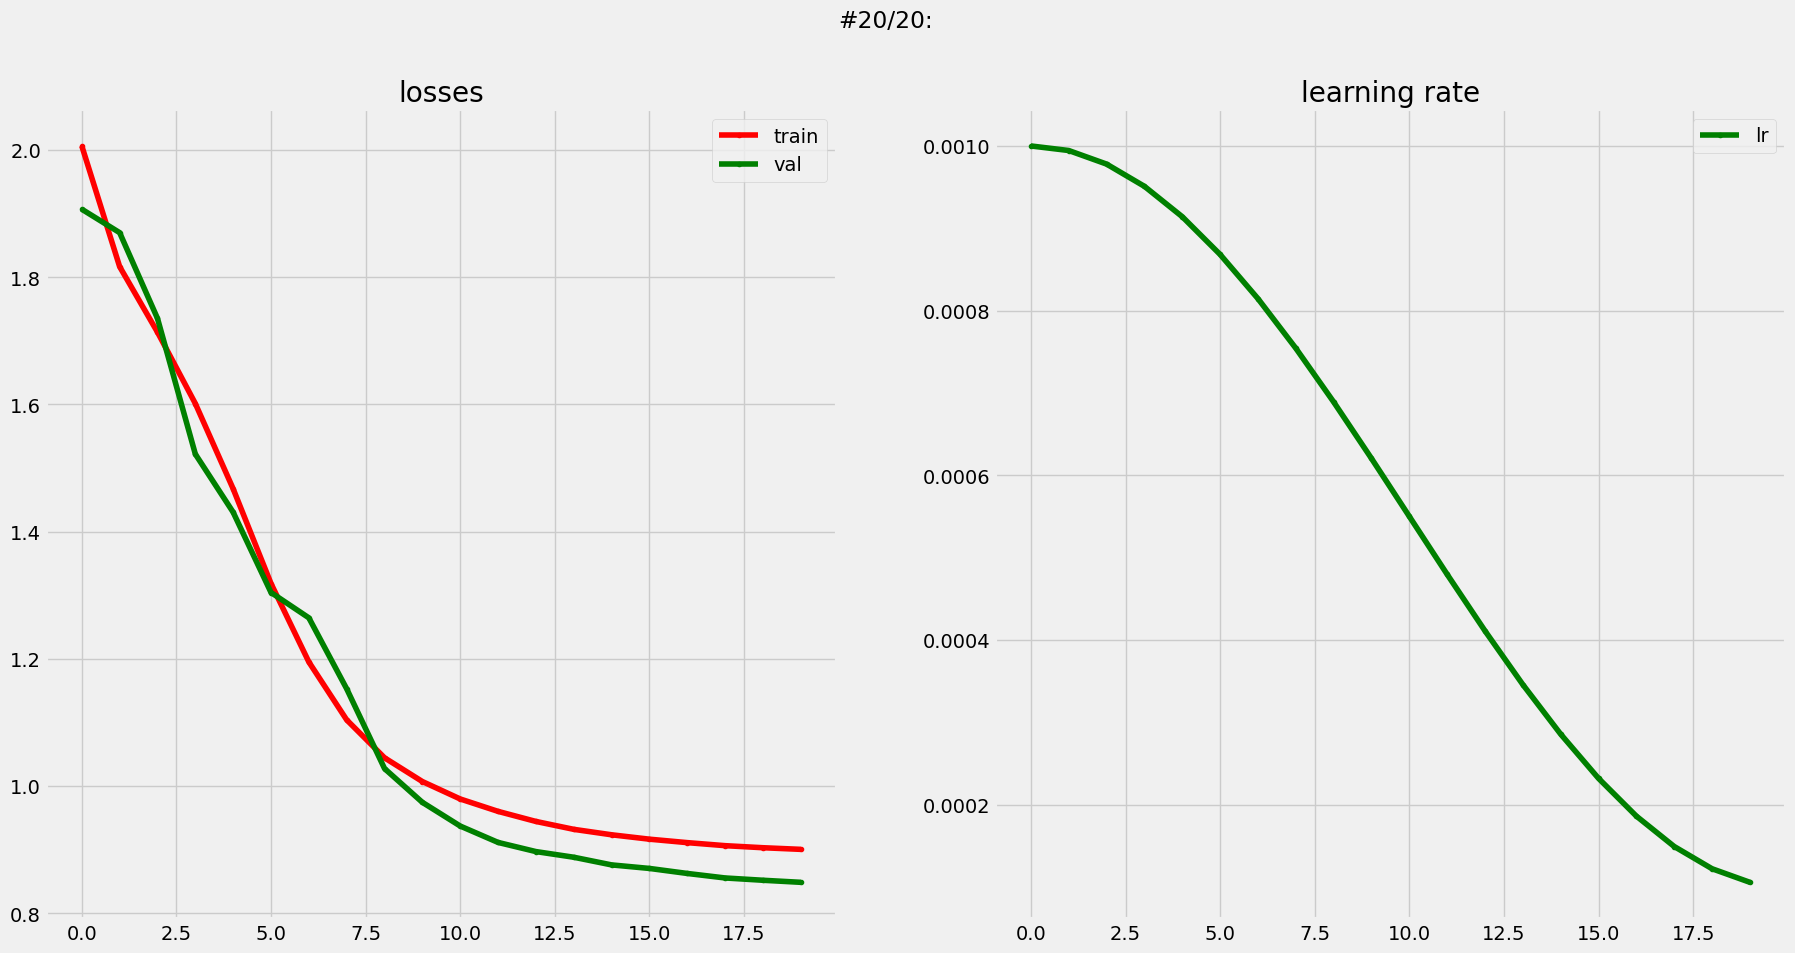

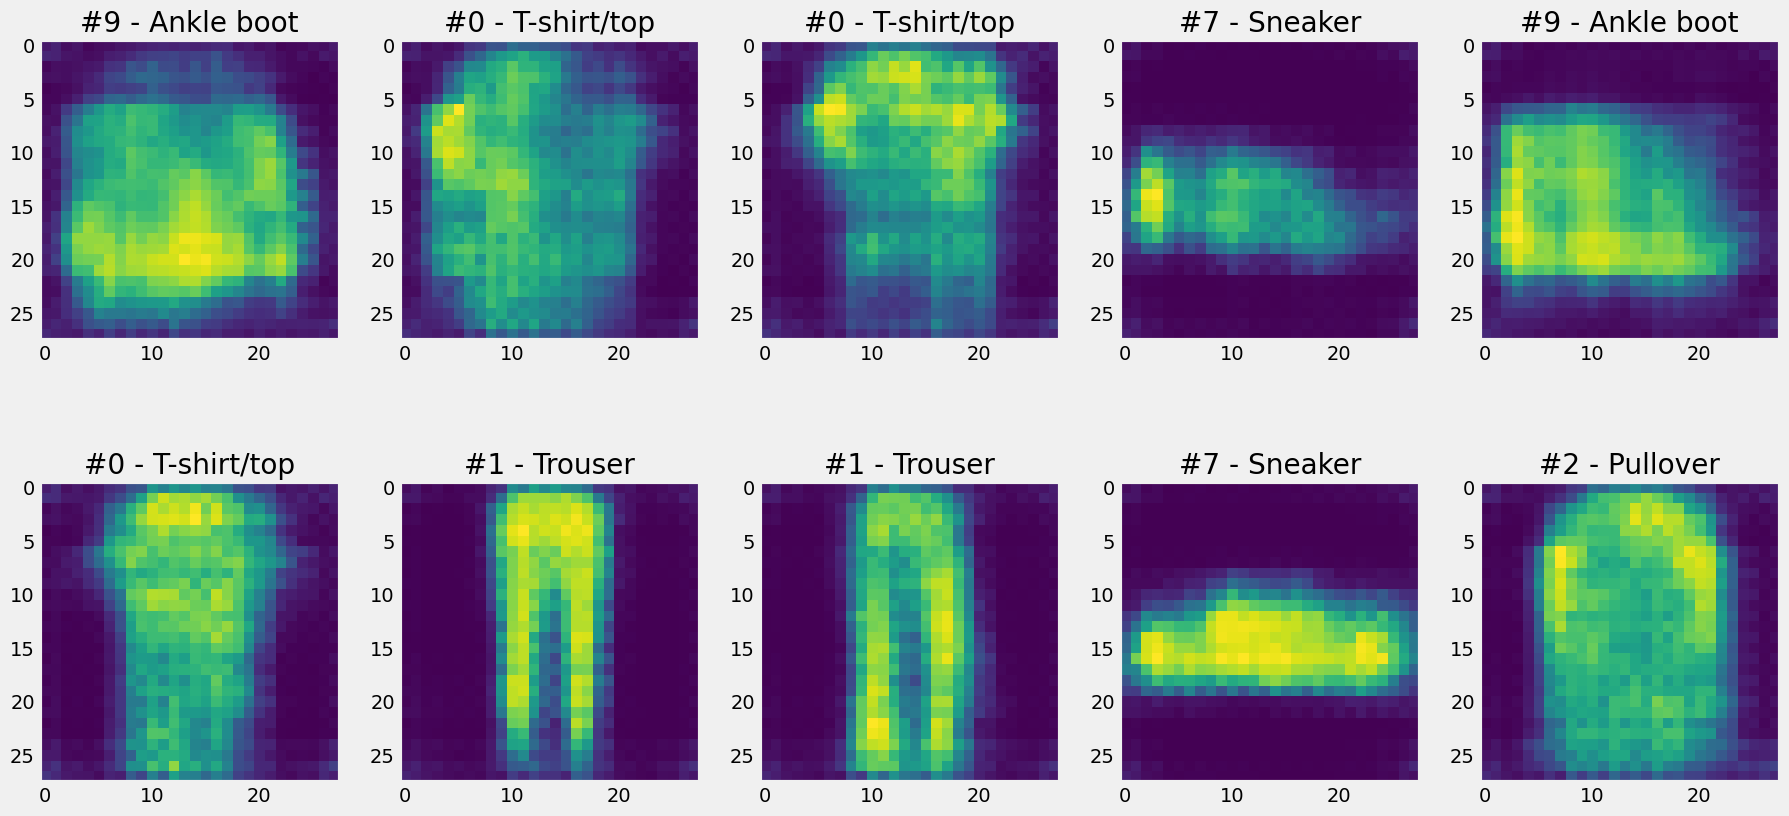

CPU times: user 6min 49s, sys: 7.78 s, total: 6min 56s
Wall time: 6min 43s


In [81]:
%%time
model, optimizer, losses = learning_loop_vae(
    model = model,
    optimizer = optimizer,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = criterion,
    scheduler = scheduler,
    epochs = 20,
    min_lr = 1e-6,
    val_every = 1,
    draw_every = 1,
    separate_show = False,
    chkp_folder = "./chkp",
    model_name = "test_cvae",
    num_classes=len(classes),
)

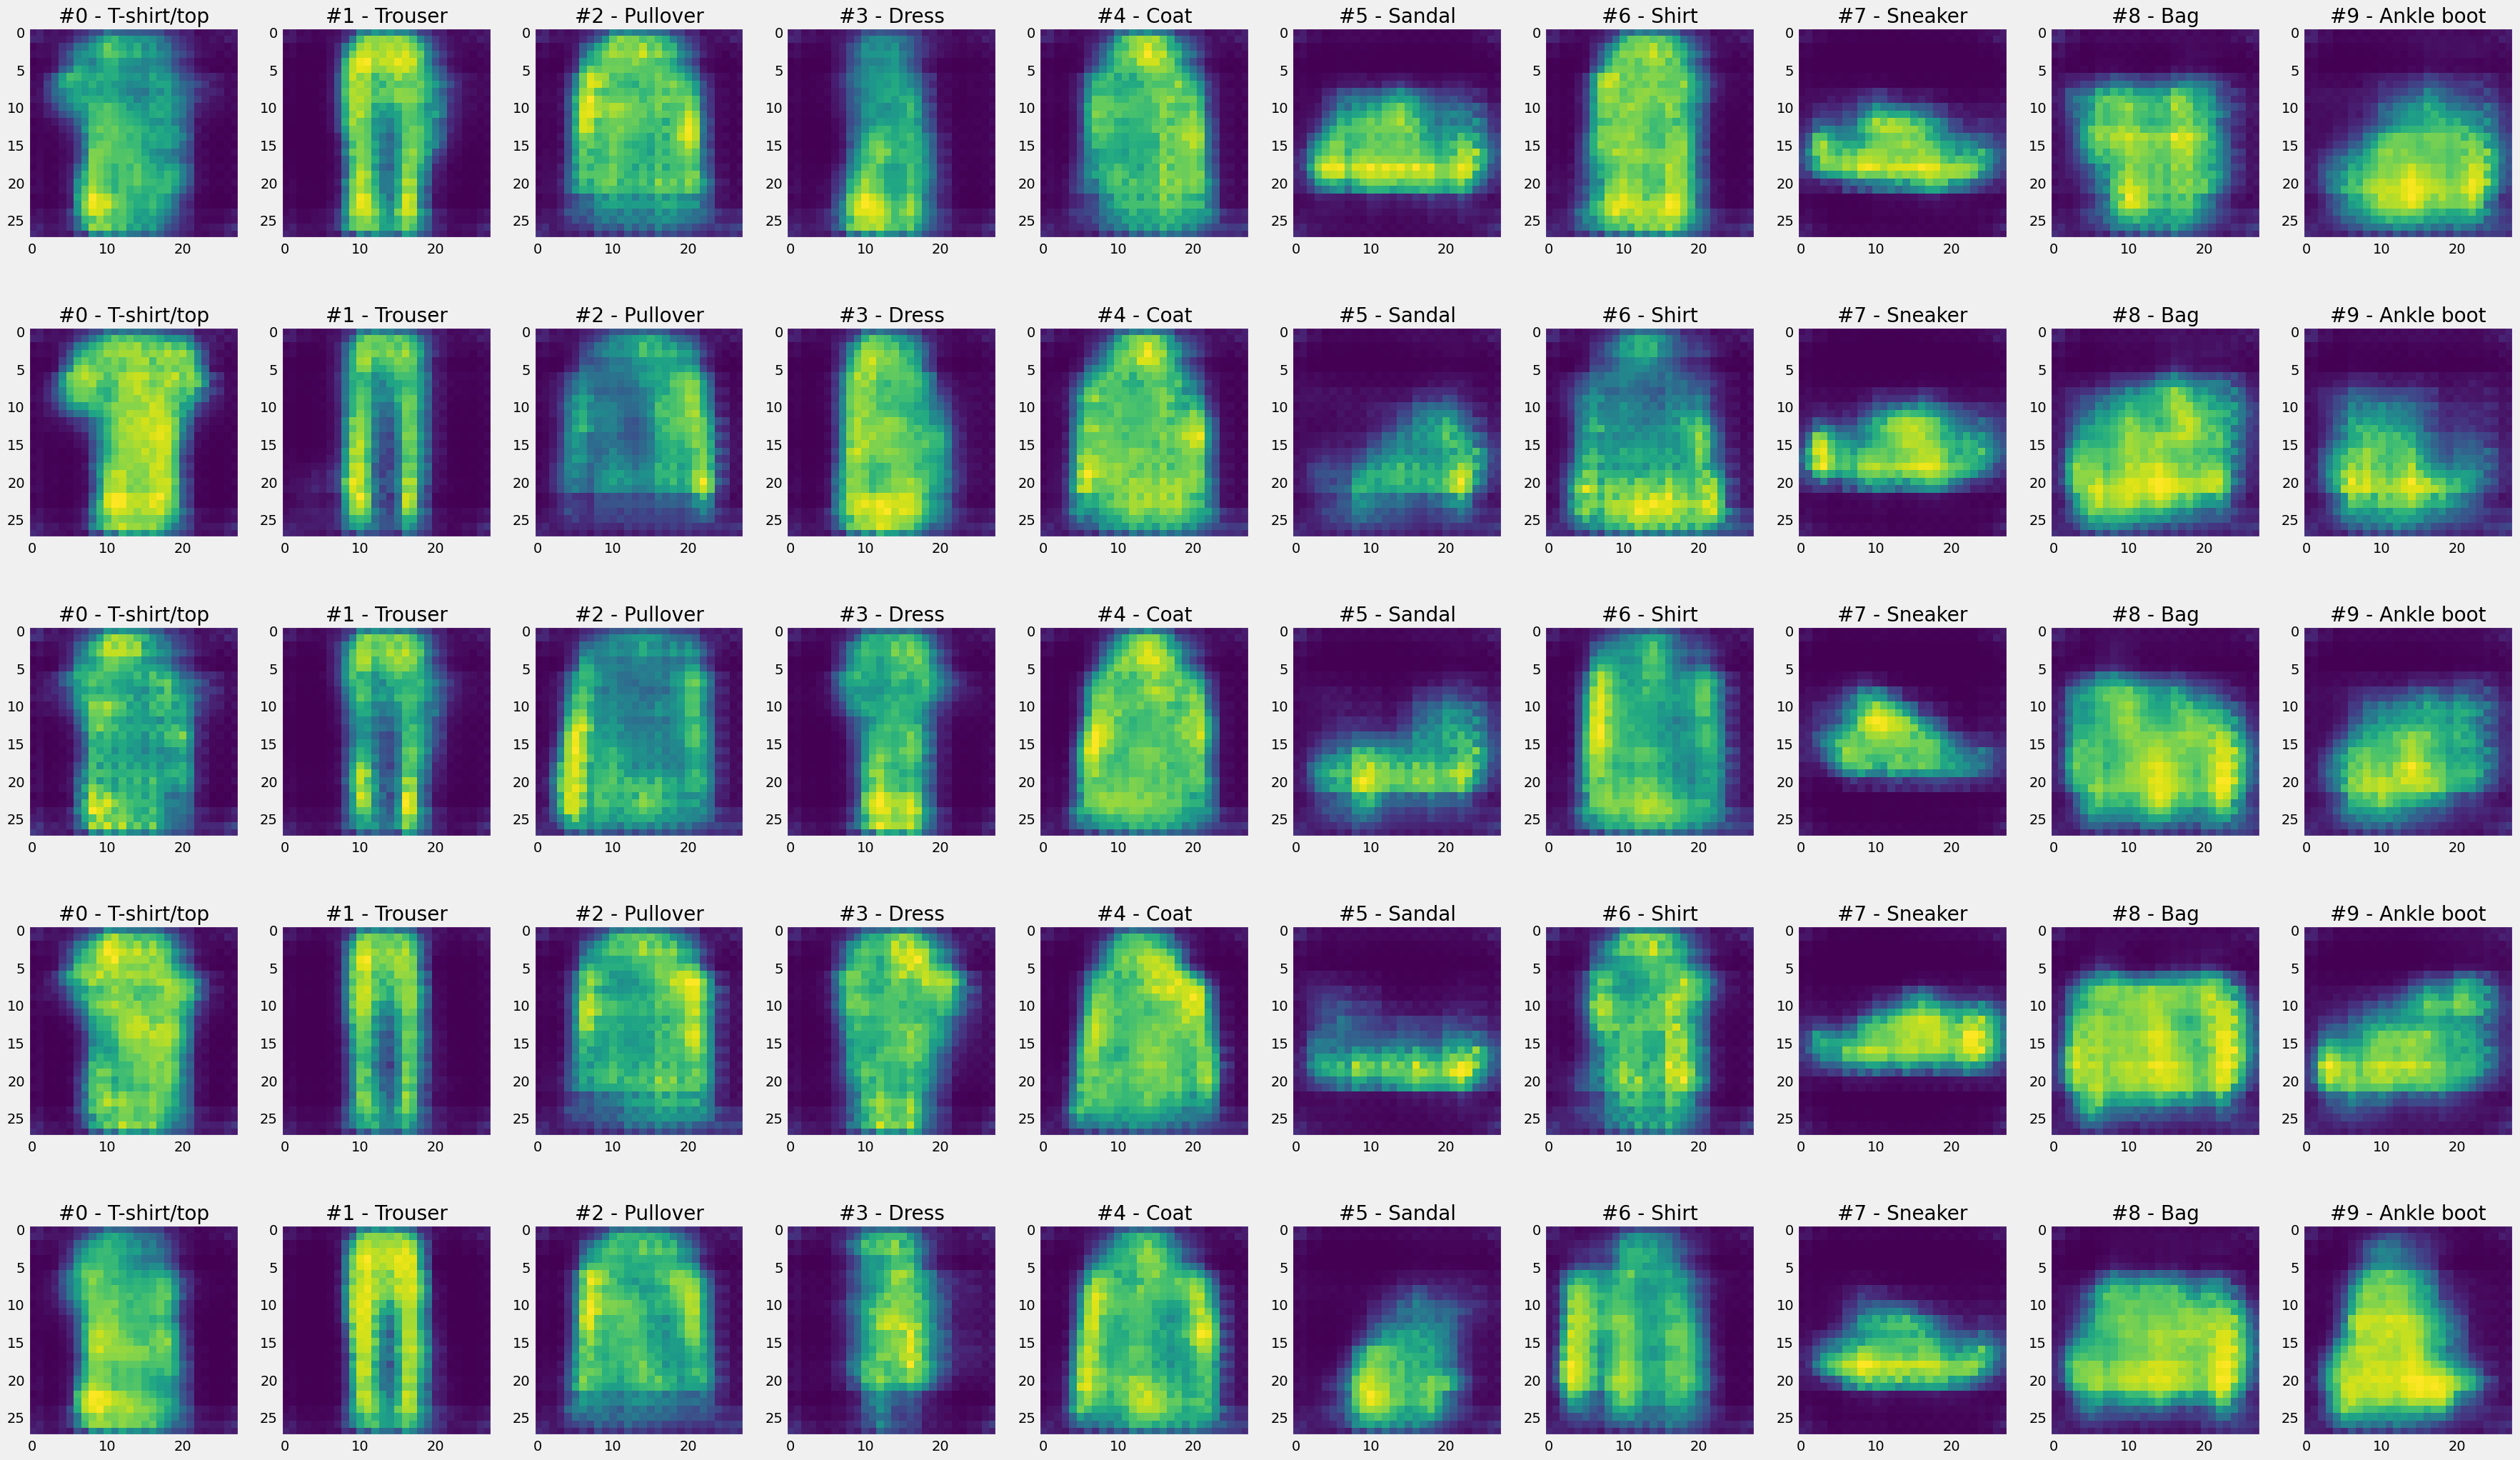

In [82]:
draw_imgs_vae(model, 5, 10, target_classes=torch.arange(10)[None, :].repeat(5, 1).reshape(-1))

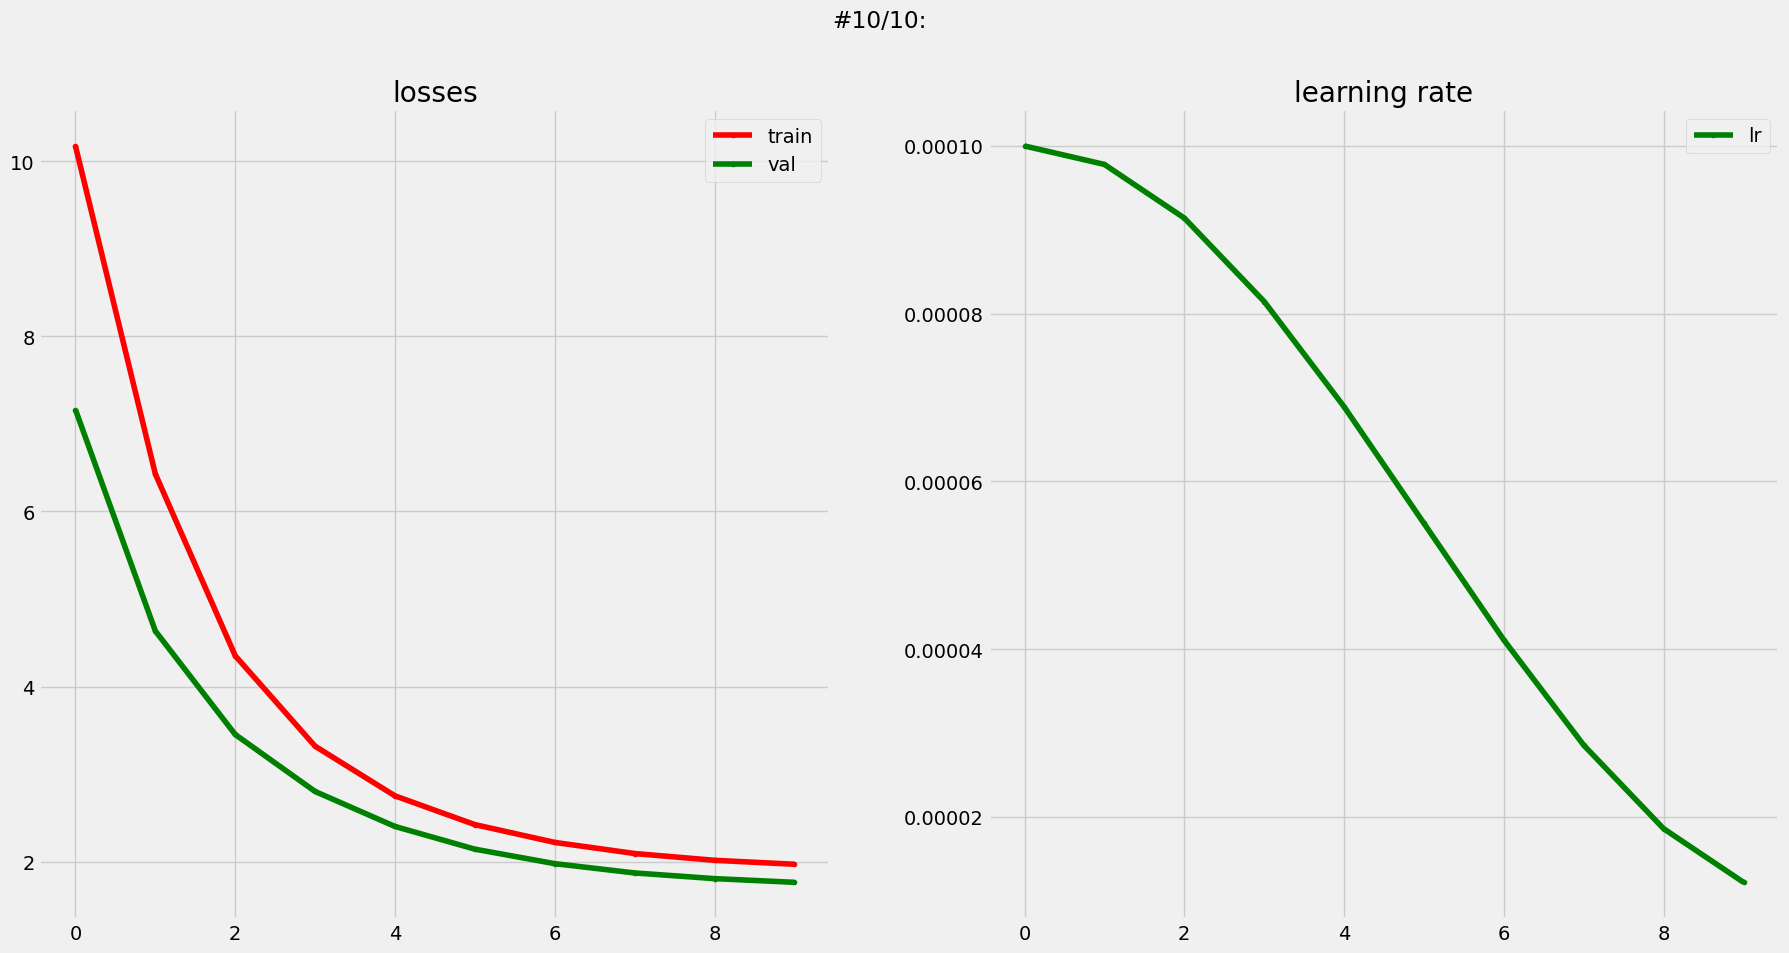

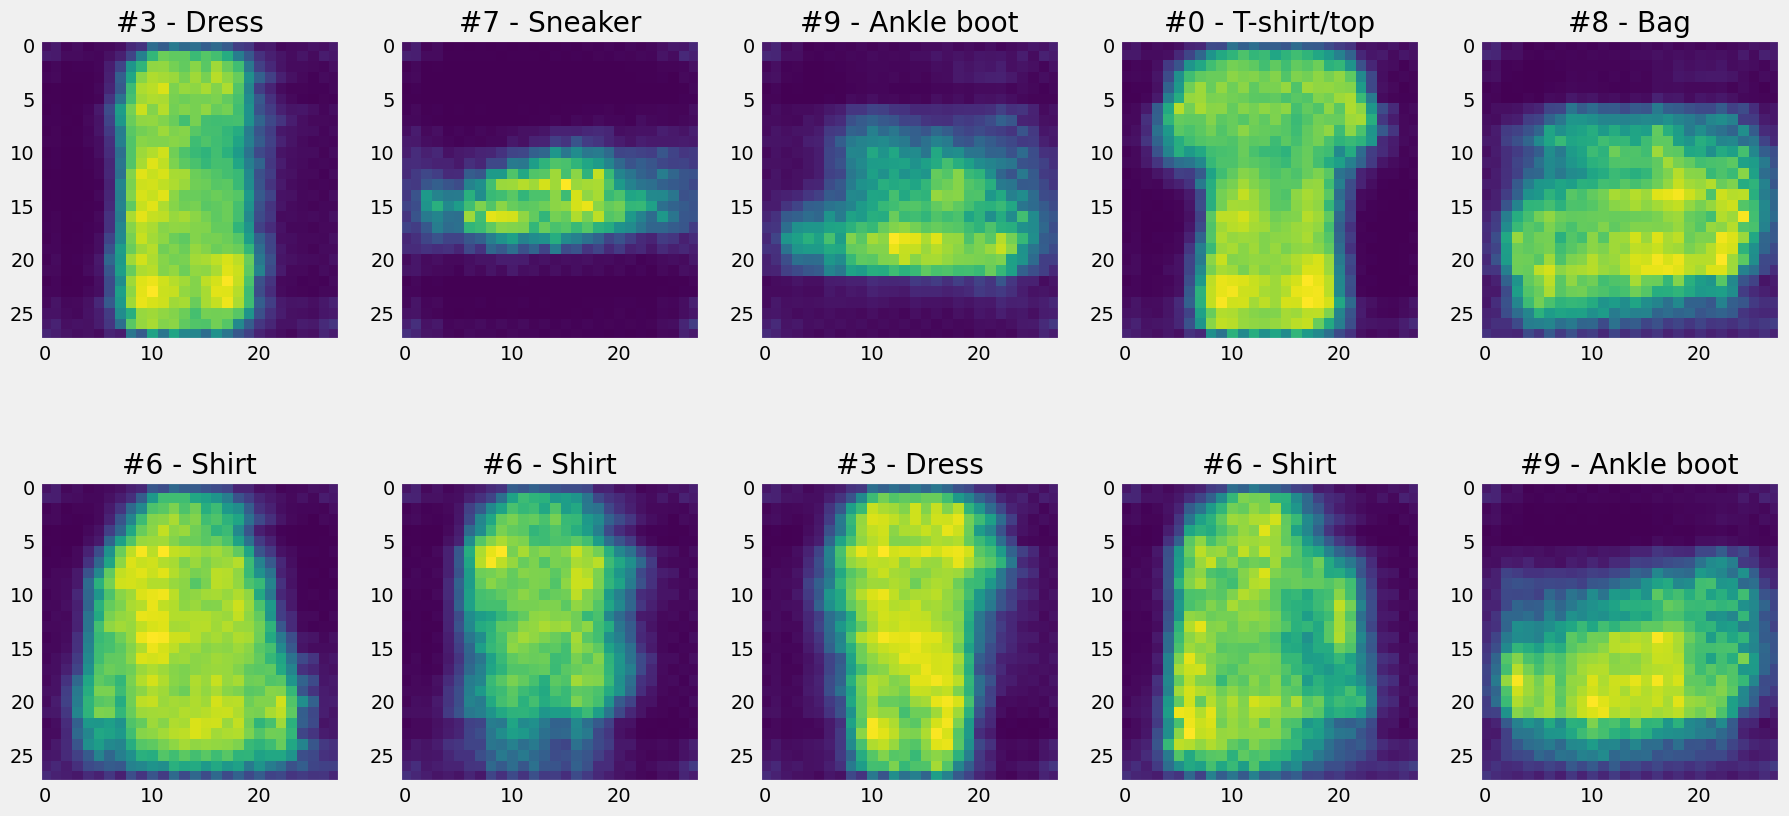

CPU times: user 3min 26s, sys: 3.78 s, total: 3min 30s
Wall time: 3min 23s


In [83]:
%%time

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-5)

criterion = partial(vae_loss, alpha=0.5, show_log=False)

model, optimizer, losses = learning_loop_vae(
    model = model,
    optimizer = optimizer,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = criterion,
    scheduler = scheduler,
    epochs = 10,
    min_lr = 1e-6,
    val_every = 1,
    draw_every = 1,
    separate_show = False,
    chkp_folder = "./chkp",
    model_name = "test_cvae",
    num_classes=len(classes),
)

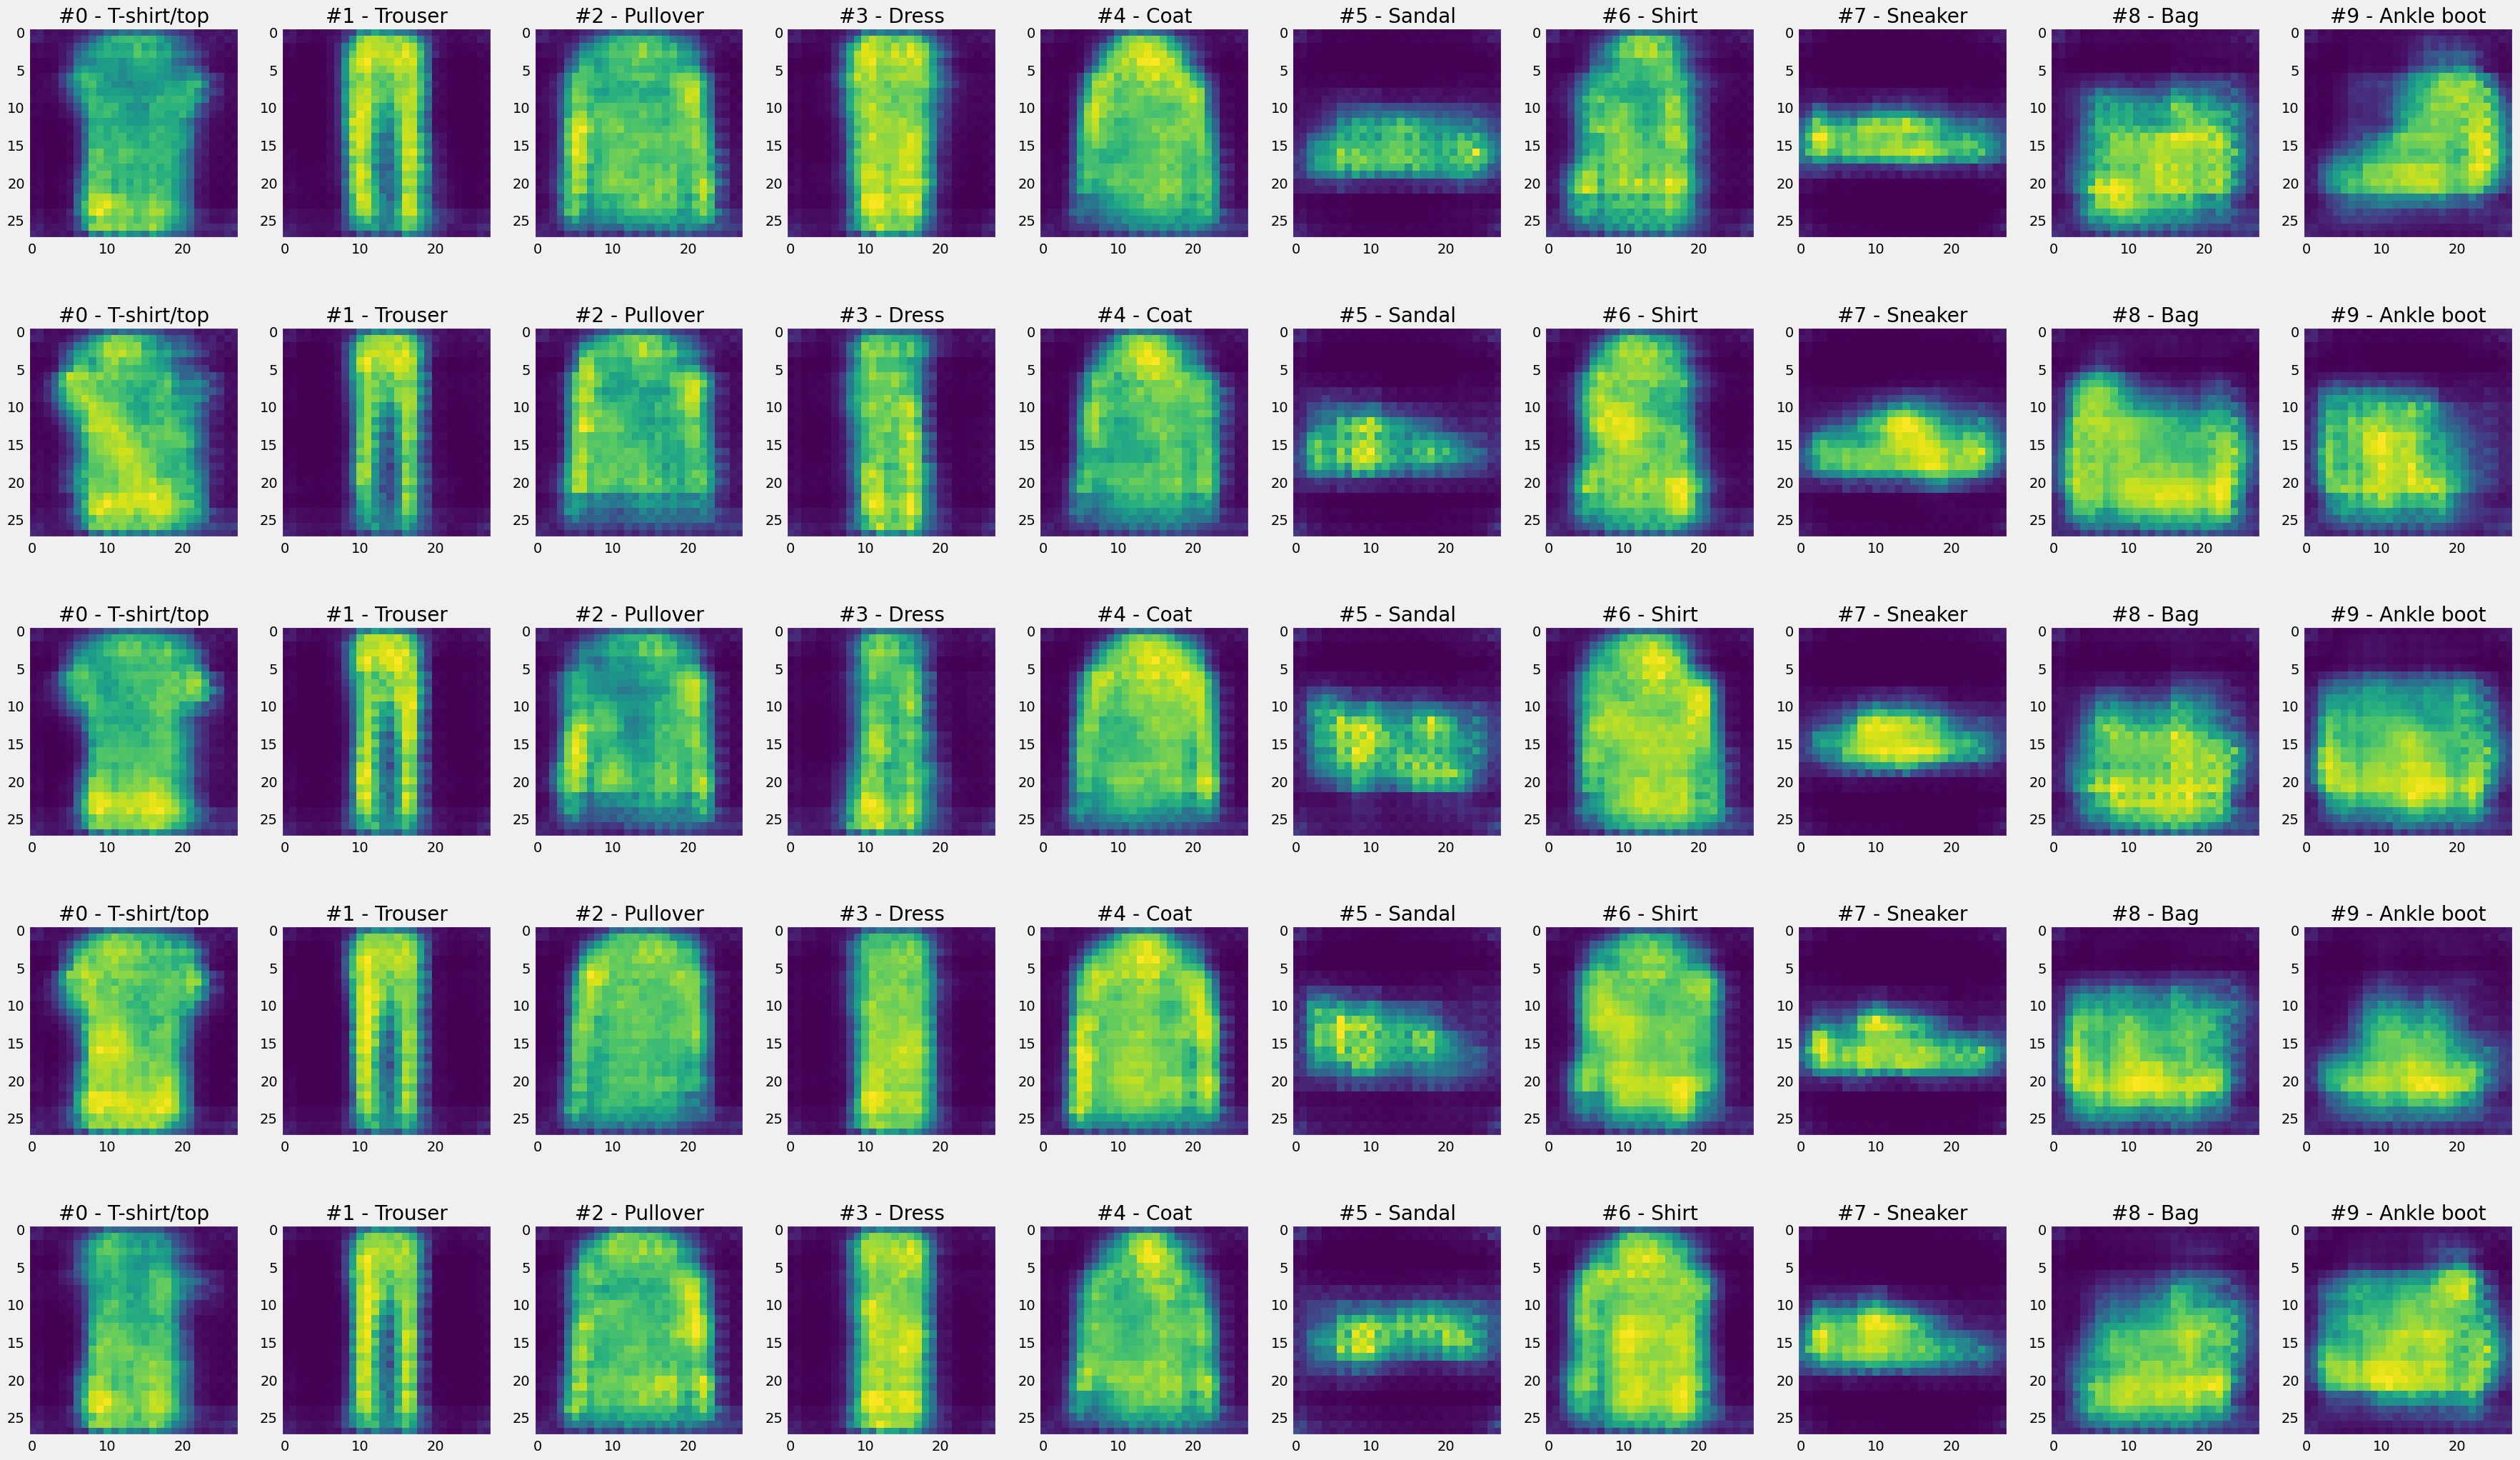

In [84]:
draw_imgs_vae(model, 5, 10, target_classes=torch.arange(10)[None, :].repeat(5, 1).reshape(-1))

### 1.6 Unconditional VAE training (for comparison)

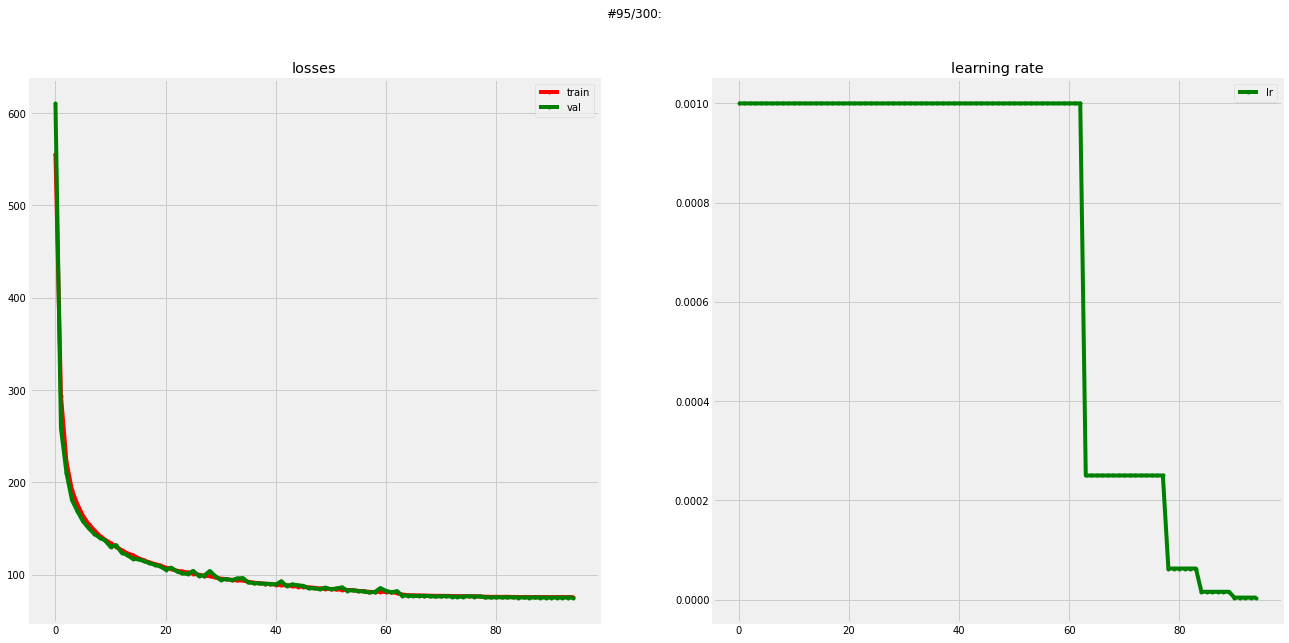

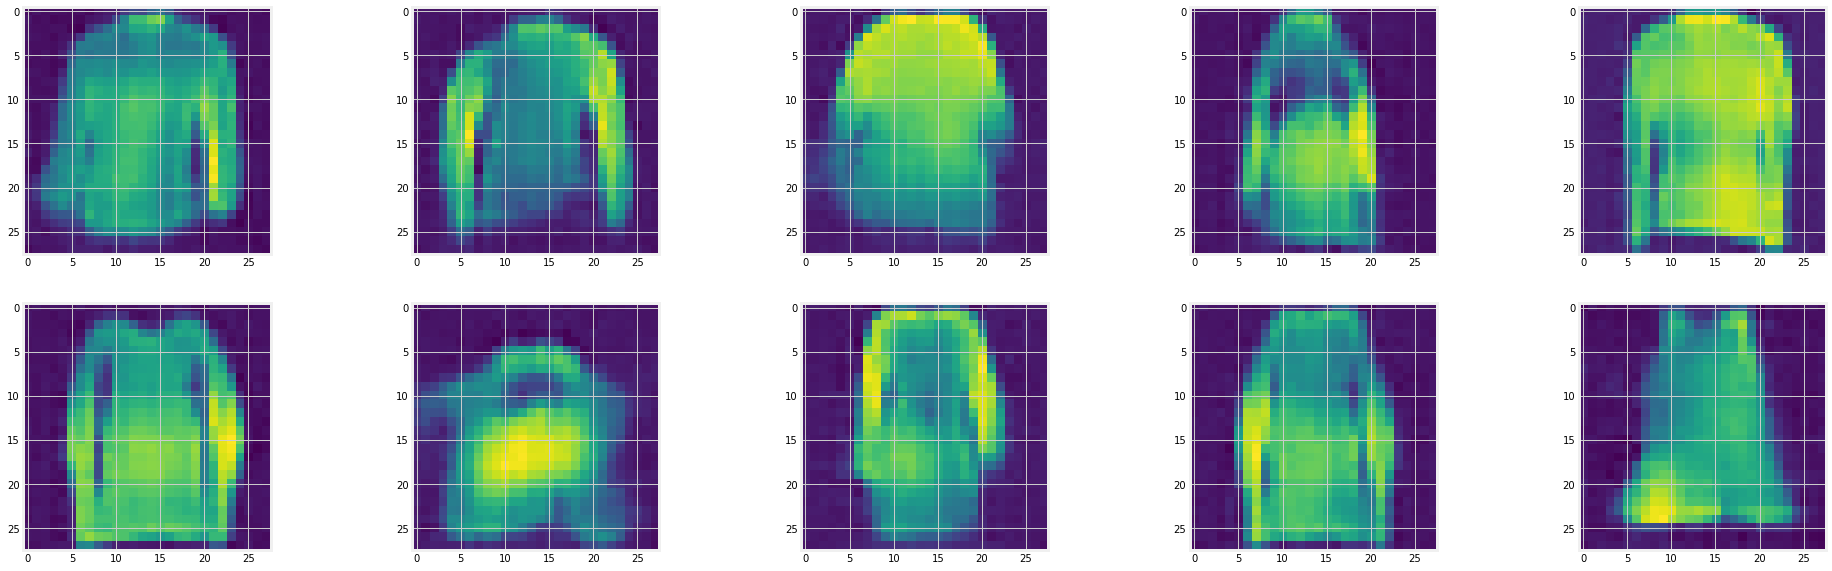

Learning process ended with early stop after epoch 95
CPU times: user 40min 25s, sys: 41 s, total: 41min 6s
Wall time: 40min 23s


In [51]:
%%time
model, optimizer, losses = learning_loop(
    model = model,
    optimizer = optimizer,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = criterion,
    scheduler = scheduler,
    epochs = 300,
    min_lr = 1e-6,
    val_every = 1,
    draw_every = 1,
    separate_show = False,
    chkp_folder = "./chkp",
    model_name = "test_vae",
)

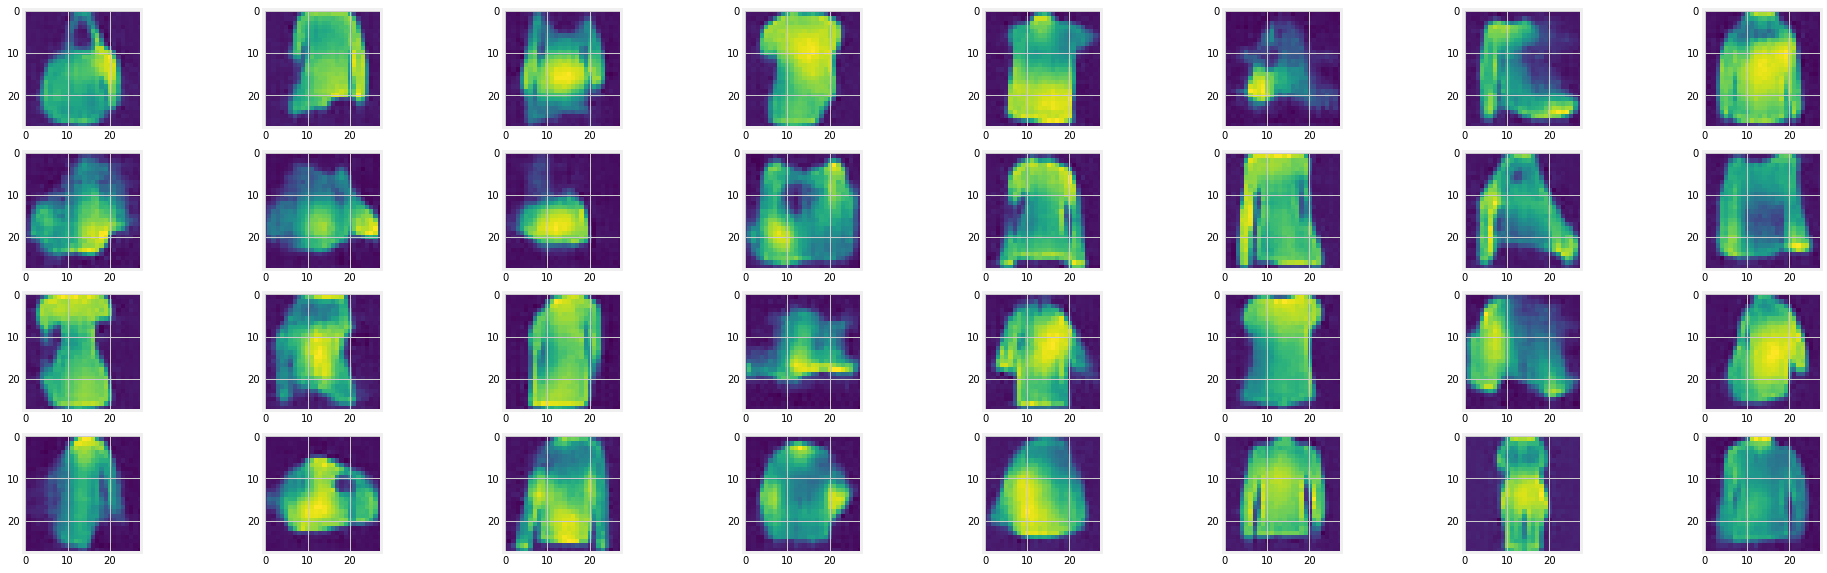

In [55]:
draw_imgs(4, 8)

## 2. Conditional GAN

### 2.1 CGAN class

In [96]:
import math

class CondGAN(nn.Module):
    def __init__(self, z_size, discr_params, gen_params):
        super(CondGAN, self).__init__()
        
        self.z_size = z_size
        self.discr_params = discr_params
        self.gen_params = gen_params
        self.hw_z = int(math.sqrt(self.z_size))
        assert self.hw_z ** 2 == self.z_size
    
        self.generator = Decoder(
            **gen_params,
        )
        
        self.discriminator = Encoder(
            **discr_params,
        )
    
    def generate_samples(self, num_samples=None, conditions=None):
        assert num_samples is None or conditions is None
        num_samples = num_samples or conditions.shape[0]
        
        z = torch.randn(num_samples, self.z_size).to(device)
        z = z.reshape(num_samples, 1, self.hw_z, self.hw_z)
        
        return F.sigmoid(self.generator(z, conditions))
    

In [97]:
def create_model_and_optimizer_gan(model_class, model_params, lr=1e-3, beta1=0.9, beta2=0.999, device=device):
    model = model_class(**model_params).float()
    model = model.to(device)
    
    optimizer_d = torch.optim.Adam([param for param in model.discriminator.parameters() if param.requires_grad], lr, [beta1, beta2])
    optimizer_g = torch.optim.Adam([param for param in model.generator.parameters() if param.requires_grad], lr, [beta1, beta2])
    return model, optimizer_d, optimizer_g


### 2.2 Train loop GAN

In [98]:
torch.nn.NLLLoss()

def train_gan_discriminator(model, opt_d, loader, criterion):
    model.train()
    losses_tr = []
    for imgs, classes in tqdm(loader):
        imgs = imgs.to(device)
        classes = classes.to(device)
        
        opt_d.zero_grad()
        pred = model.discriminator(imgs, classes)
        gen_imgs = model.generate_samples(conditions=classes)
        gen_pred = model.discriminator(gen_imgs, classes)
        
        full_pred = torch.cat((pred, gen_pred), dim=0)
        is_real = torch.cat(
            (
                torch.ones(pred.shape[0]),
                torch.zeros(gen_pred.shape[0]),
            )
        ).to(device, dtype=torch.long)
        
        loss = criterion(full_pred, is_real)
        
        loss.backward()
        opt_d.step()
        losses_tr.append(loss.item())
    
    return model, opt_d, np.mean(losses_tr)


def train_gan_generator(model, opt_g, loader, criterion):
    model.train()
    losses_tr = []
    
    for _, classes in tqdm(loader):
        classes = classes.to(device)
        
        opt_g.zero_grad()
        gen_imgs = model.generate_samples(conditions=classes)
        gen_pred = model.discriminator(gen_imgs, classes)

        loss = criterion(gen_pred, torch.ones(gen_pred.shape[0]).to(device, dtype=torch.long))

        loss.backward()
        opt_g.step()
        losses_tr.append(loss.item())
    
    return model, opt_g, np.mean(losses_tr)


def val_gan(model, loader, criterion):
    model.eval()
    discr_losses_val = []
    gen_losses_val = []
    all_real_pred = []
    all_gen_pred = []
    with torch.no_grad():
        for imgs, classes in tqdm(loader):
            imgs = imgs.to(device)
            classes = classes.to(device)
            
            pred = model.discriminator(imgs, classes)
            gen_imgs = model.generate_samples(conditions=classes)
            gen_pred = model.discriminator(gen_imgs, classes)
            
            all_real_pred.extend(F.softmax(pred, dim=1)[:, 1].cpu().detach().tolist())
            all_gen_pred.extend(F.softmax(gen_pred, dim=1)[:, 1].cpu().detach().tolist())
            
            full_pred = torch.cat((pred, gen_pred), dim=0)
            is_real = torch.cat(
                (
                    torch.ones(pred.shape[0]),
                    torch.zeros(gen_pred.shape[0]),
                )
            ).to(device, dtype=torch.long)
            
            loss_d = criterion(full_pred, is_real)
            loss_g = criterion(gen_pred, torch.ones(gen_pred.shape[0]).to(device, dtype=torch.long))

            discr_losses_val.append(loss_d.item())
            gen_losses_val.append(loss_g.item())
    
    return np.mean(discr_losses_val), np.mean(gen_losses_val), all_real_pred, all_gen_pred

In [99]:
results_gan = []

def draw_imgs_gan(model, h, w, num_classes=0, target_classes=None):
    global results_gan
    model.eval()
    fig, ax = plt.subplots(h, w, figsize=(4*w, 5*h))
    with torch.no_grad():
        assert target_classes is None or num_classes == 0
        c = None
        if num_classes > 0:
            c = torch.randint(num_classes, size=(h*w,)).to(device)
        if target_classes is not None:
            assert target_classes.shape[0] == h * w
            c = target_classes.to(device)
        
        pred = model.generate_samples(conditions=c)
        to_draw = [de_normalize(pred[ind]) for ind in range(h * w)]
        results_gan.append((copy.deepcopy(to_draw), c))
        
        for hh in range(h):
            for ww in range(w):
                ind = hh * w + ww
                plt.subplot(h, w, ind + 1)
                if c is not None:
                    plt.title(f"#{c[ind]} - {classes[c[ind]]}")
                plt.imshow(to_draw[ind])
                plt.grid()
    plt.show()

In [100]:
def learning_loop_gan(
    model,
    optimizer_g,
    g_iters_per_epoch,
    optimizer_d,
    d_iters_per_epoch,
    train_loader,
    val_loader,
    criterion,
    scheduler_g=None,
    scheduler_d=None,
    min_lr=None,
    epochs=10,
    val_every=1,
    draw_every=1,
    model_name=None,
    chkp_folder="./chkps",
    num_classes=0,
    plots=None,
    starting_epoch=0,
):
    model_name = get_model_name(chkp_folder, model_name)
    
    if plots is None:
        plots = {
            'train G': [],
            'train D': [],
            'val D': [],
            'val G': [],
            "lr G": [],
            "lr D": [],
            "hist real": [],
            "hist gen": [],
        }

    for epoch in np.arange(1, epochs+1) + starting_epoch:
        print(f'#{epoch}/{epochs}:')

        plots['lr G'].append(get_lr(optimizer_g))
        plots['lr D'].append(get_lr(optimizer_d))
        
        # train discriminator
        print(f"train discriminator ({d_iters_per_epoch} times)")
        loss_d = []
        for _ in range(d_iters_per_epoch):
            model, optimizer_d, loss = train_gan_discriminator(model, optimizer_d, train_loader, criterion)
            loss_d.append(loss)
        plots['train D'].extend(loss_d)
        
        # train generator
        print(f"train generator ({g_iters_per_epoch} times)")
        loss_g = []
        for _ in range(g_iters_per_epoch):
            model, optimizer_g, loss = train_gan_generator(model, optimizer_g, train_loader, criterion)
            loss_g.append(loss)
        plots['train G'].extend(loss_g)

        if not (epoch % val_every):
            print("validate")
            loss_d, loss_g, real_pred, gen_pred = val_gan(model, val_loader, criterion)
            plots['val D'].append(loss_d)
            plots['val G'].append(loss_g)
            plots['hist gen'].append(gen_pred)
            plots['hist real'].append(real_pred)
            
            # Сохраняем модель
            if not os.path.exists(chkp_folder):
                os.makedirs(chkp_folder)
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'plots': plots,
                },
                os.path.join(chkp_folder, model_name + '.pt'),
            )
            
            # Шедулинг
            if scheduler_d:
                try:
                    scheduler_d.step()
                except:
                    scheduler_d.step(loss_d)
            if scheduler_g:
                try:
                    scheduler_g.step()
                except:
                    scheduler_g.step(loss_g)

        if not (epoch % draw_every):
            clear_output(True)
            
            ww = 4
            fig, ax = plt.subplots(1, ww, figsize=(25, 12))
            fig.suptitle(f'#{epoch}/{epochs}:')

            plt.subplot(1, ww, 1)
            plt.title('discriminator losses')
            d_plot_step = 1. / d_iters_per_epoch
            plt.plot(np.arange(d_plot_step, epoch + d_plot_step, d_plot_step), plots['train D'], 'r.-', label='train', alpha=0.7)
            plt.plot(np.arange(1, epoch + 1), plots['val D'], 'g.-', label='val', alpha=0.7)
            plt.legend()
            
            plt.subplot(1, ww, 2)
            plt.title('generator losses')
            g_plot_step = 1. / g_iters_per_epoch
            plt.plot(np.arange(g_plot_step, epoch + g_plot_step, g_plot_step), plots['train G'], 'r.-', label='train', alpha=0.7)
            plt.plot(np.arange(1, epoch + 1), plots['val G'], 'g.-', label='val', alpha=0.7)
            plt.legend()
            
            plt.subplot(1, ww, 3)
            plt.title('learning rates')
            plt.plot(plots["lr D"], 'b.-', label='lr discriminator', alpha=0.7)
            plt.plot(plots["lr G"], 'm.-', label='lr generator', alpha=0.7)
            plt.legend()
            
            plt.subplot(1, ww, 4)
            plt.title("Discriminator predictions")
            plt.hist(plots["hist real"][-1], bins=50, density=True, label="real", color="green", alpha=0.7)
            plt.hist(plots["hist gen"][-1], bins=50, density=True, label="generated", color="red", alpha=0.7)
            plt.xlim((-0.05, 1.05))
            plt.xticks(ticks=np.arange(0, 1.05, 0.1))
            plt.legend()
            
            plt.show()
            
            draw_imgs_gan(model, 2, 5, num_classes=num_classes)
                
        
        if min_lr and get_lr(optimizer_d) <= min_lr:
            print(f'Learning process ended with early stop for discriminator after epoch {epoch}')
            break
        
        if min_lr and get_lr(optimizer_g) <= min_lr:
            print(f'Learning process ended with early stop for generator after epoch {epoch}')
            break
    
    return model, optimizer_d, optimizer_g, plots

### 2.3 Training CGAN

In [109]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

z_size = 16
discr_cond_emb_size = 10
gen_cond_emb_size = 10
cond_n_class = len(classes)

results = []

model, optimizer_d, optimizer_g = create_model_and_optimizer_gan(
    model_class = CondGAN,
    model_params = dict(
        z_size = z_size,
        discr_params = dict(
            num_blocks=4,
            block_sizes=2,
            hidden_sizes=[4, 8, 16, 32],
            kernel_sizes=3,
            activation_classes=nn.ReLU,
            use_scales=[True, True, True, False],
            change_sizes=[0, 0, 1, 0],
            dropout_ps=[0, 0, 0.1, 0.2],
            fc_size=2,  # чтобы предсказывать 0 (fake) или 1 (real) класс
            # Новые параметры
            cond_n_class=cond_n_class,
            cond_emb_size=discr_cond_emb_size,
        ),
        gen_params = dict(
            num_blocks=4,
            block_sizes=2,
            hidden_sizes=[1, 32, 16, 8, 1],
            kernel_sizes=3,
            activation_classes=[nn.ReLU, nn.ReLU, nn.ReLU, nn.Identity],
            use_scales=[False, True, True, False],
            change_sizes=[0, 2, 2, 0],
            dropout_ps=[0.2, 0.1, 0, 0],
            # Новые параметры
            cond_n_class=cond_n_class,
            cond_emb_size=gen_cond_emb_size,
        ),
    ),
    lr = 1e-3,
    device = device,
)


# scheduler_d = None
# scheduler_g = None

scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_d, T_max=20, eta_min=1e-5, verbose=True)
scheduler_g = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_g, T_max=20, eta_min=1e-5, verbose=True)

# scheduler_d = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_d, mode='min', factor=0.25, patience=4, threshold=0.001, verbose=True)
# scheduler_g = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_g, mode='min', factor=0.25, patience=4, threshold=0.001, verbose=True)

criterion = torch.nn.CrossEntropyLoss()

sum_params, sum_learnable_params = model_num_params(model)

generator.cond_adapt.weight                                       ~  100       params ~ grad: True
generator.residual_blocks.residual_0.layers.layer_0.deconv.weight ~  3.168     params ~ grad: True
generator.residual_blocks.residual_0.layers.layer_0.bnorm.weight  ~  32        params ~ grad: True
generator.residual_blocks.residual_0.layers.layer_0.bnorm.bias    ~  32        params ~ grad: True
generator.residual_blocks.residual_0.layers.layer_1.deconv.weight ~  9.216     params ~ grad: True
generator.residual_blocks.residual_0.layers.layer_1.bnorm.weight  ~  32        params ~ grad: True
generator.residual_blocks.residual_0.layers.layer_1.bnorm.bias    ~  32        params ~ grad: True
generator.residual_blocks.residual_0.adapt_residual.weight        ~  352       params ~ grad: True
generator.residual_blocks.residual_0.adapt_residual.bias          ~  32        params ~ grad: True
generator.residual_blocks.residual_1.layers.layer_0.deconv.weight ~  4.608     params ~ grad: True
generator.

/home/jupyter/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [110]:
model

CondGAN(
  (generator): Decoder(
    (cond_adapt): Embedding(10, 10)
    (residual_blocks): Sequential(
      (residual_0): ResidualBlock(
        (layers): Sequential(
          (layer_0): Sequential(
            (deconv): ConvTranspose2d(11, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bnorm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): ReLU()
            (drop): Dropout2d(p=0.2, inplace=False)
          )
          (layer_1): Sequential(
            (deconv): ConvTranspose2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bnorm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): ReLU()
            (drop): Dropout2d(p=0.2, inplace=False)
          )
        )
        (adapt_residual): ConvTranspose2d(11, 32, kernel_size=(1, 1), stride=(1, 1))
        (scale): Sequential(
          (add_size): Identity()
        

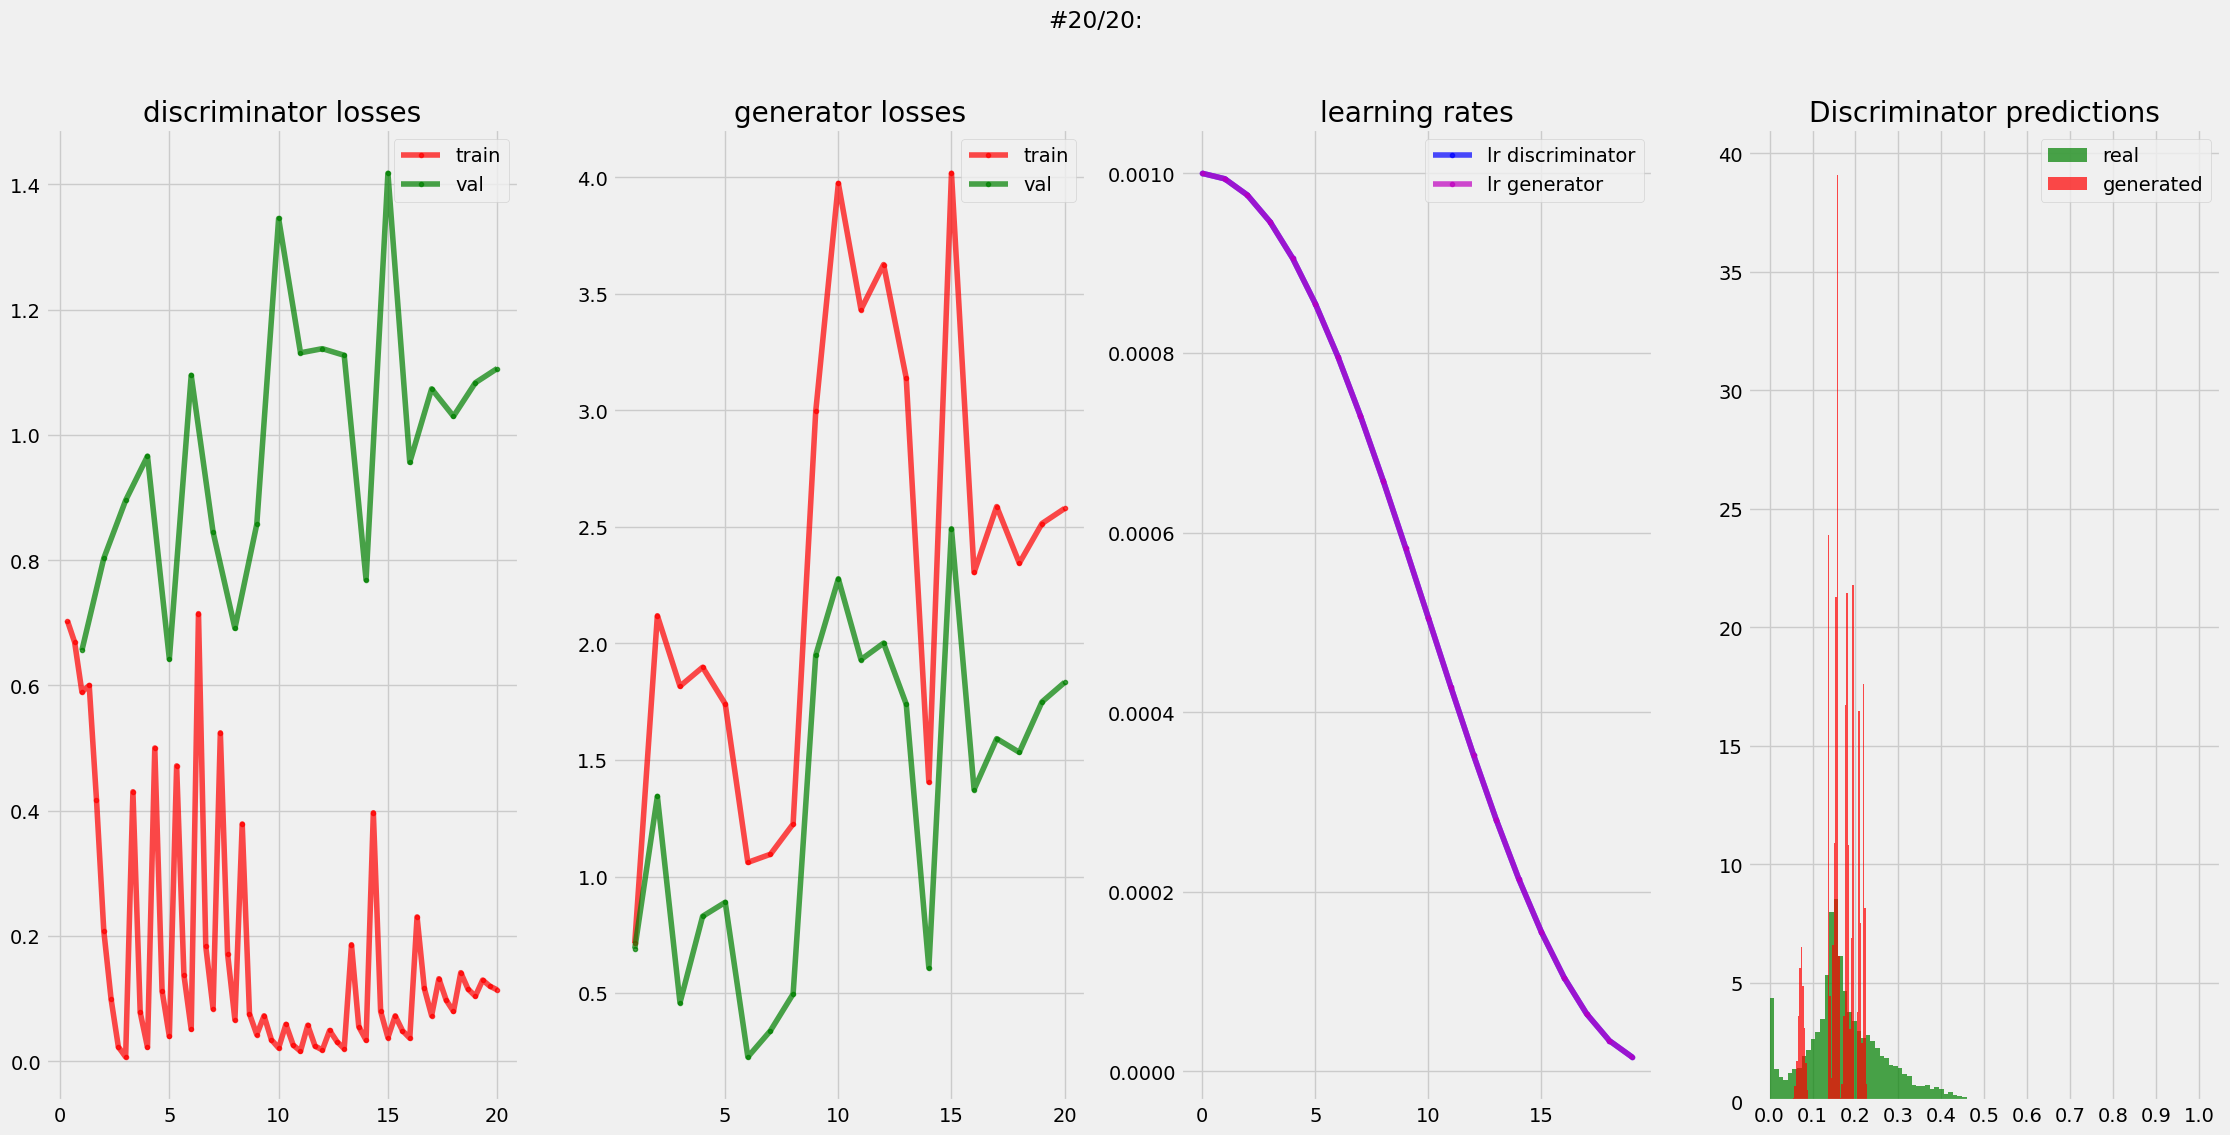

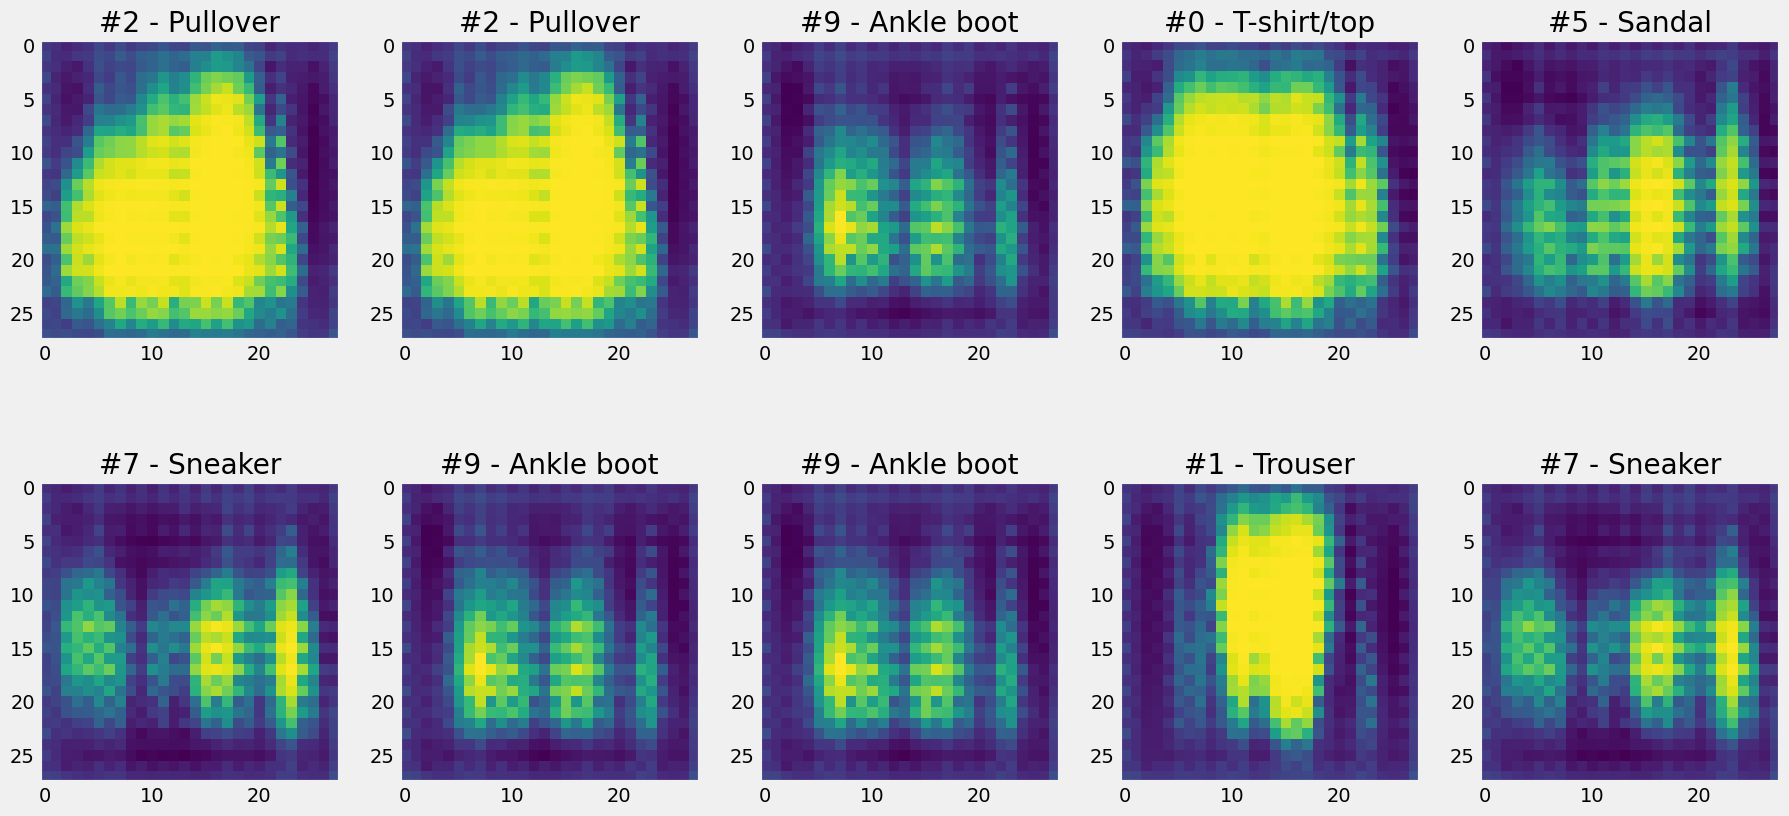

CPU times: user 23min 27s, sys: 11.3 s, total: 23min 39s
Wall time: 23min 20s


In [111]:
%%time
model, optimizer_d, optimizer_g, plots = learning_loop_gan(
    model = model,
    optimizer_g = optimizer_g,
    g_iters_per_epoch = 1,
    optimizer_d = optimizer_d,
    d_iters_per_epoch = 3,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = criterion,
    scheduler_g = scheduler_g,
    scheduler_d = scheduler_d,
    epochs = 20,
    min_lr = 1e-6,
    val_every = 1,
    draw_every = 1,
    chkp_folder = "./chkp",
    model_name = "test_cgan",
    num_classes=len(classes),
    plots=None,
)

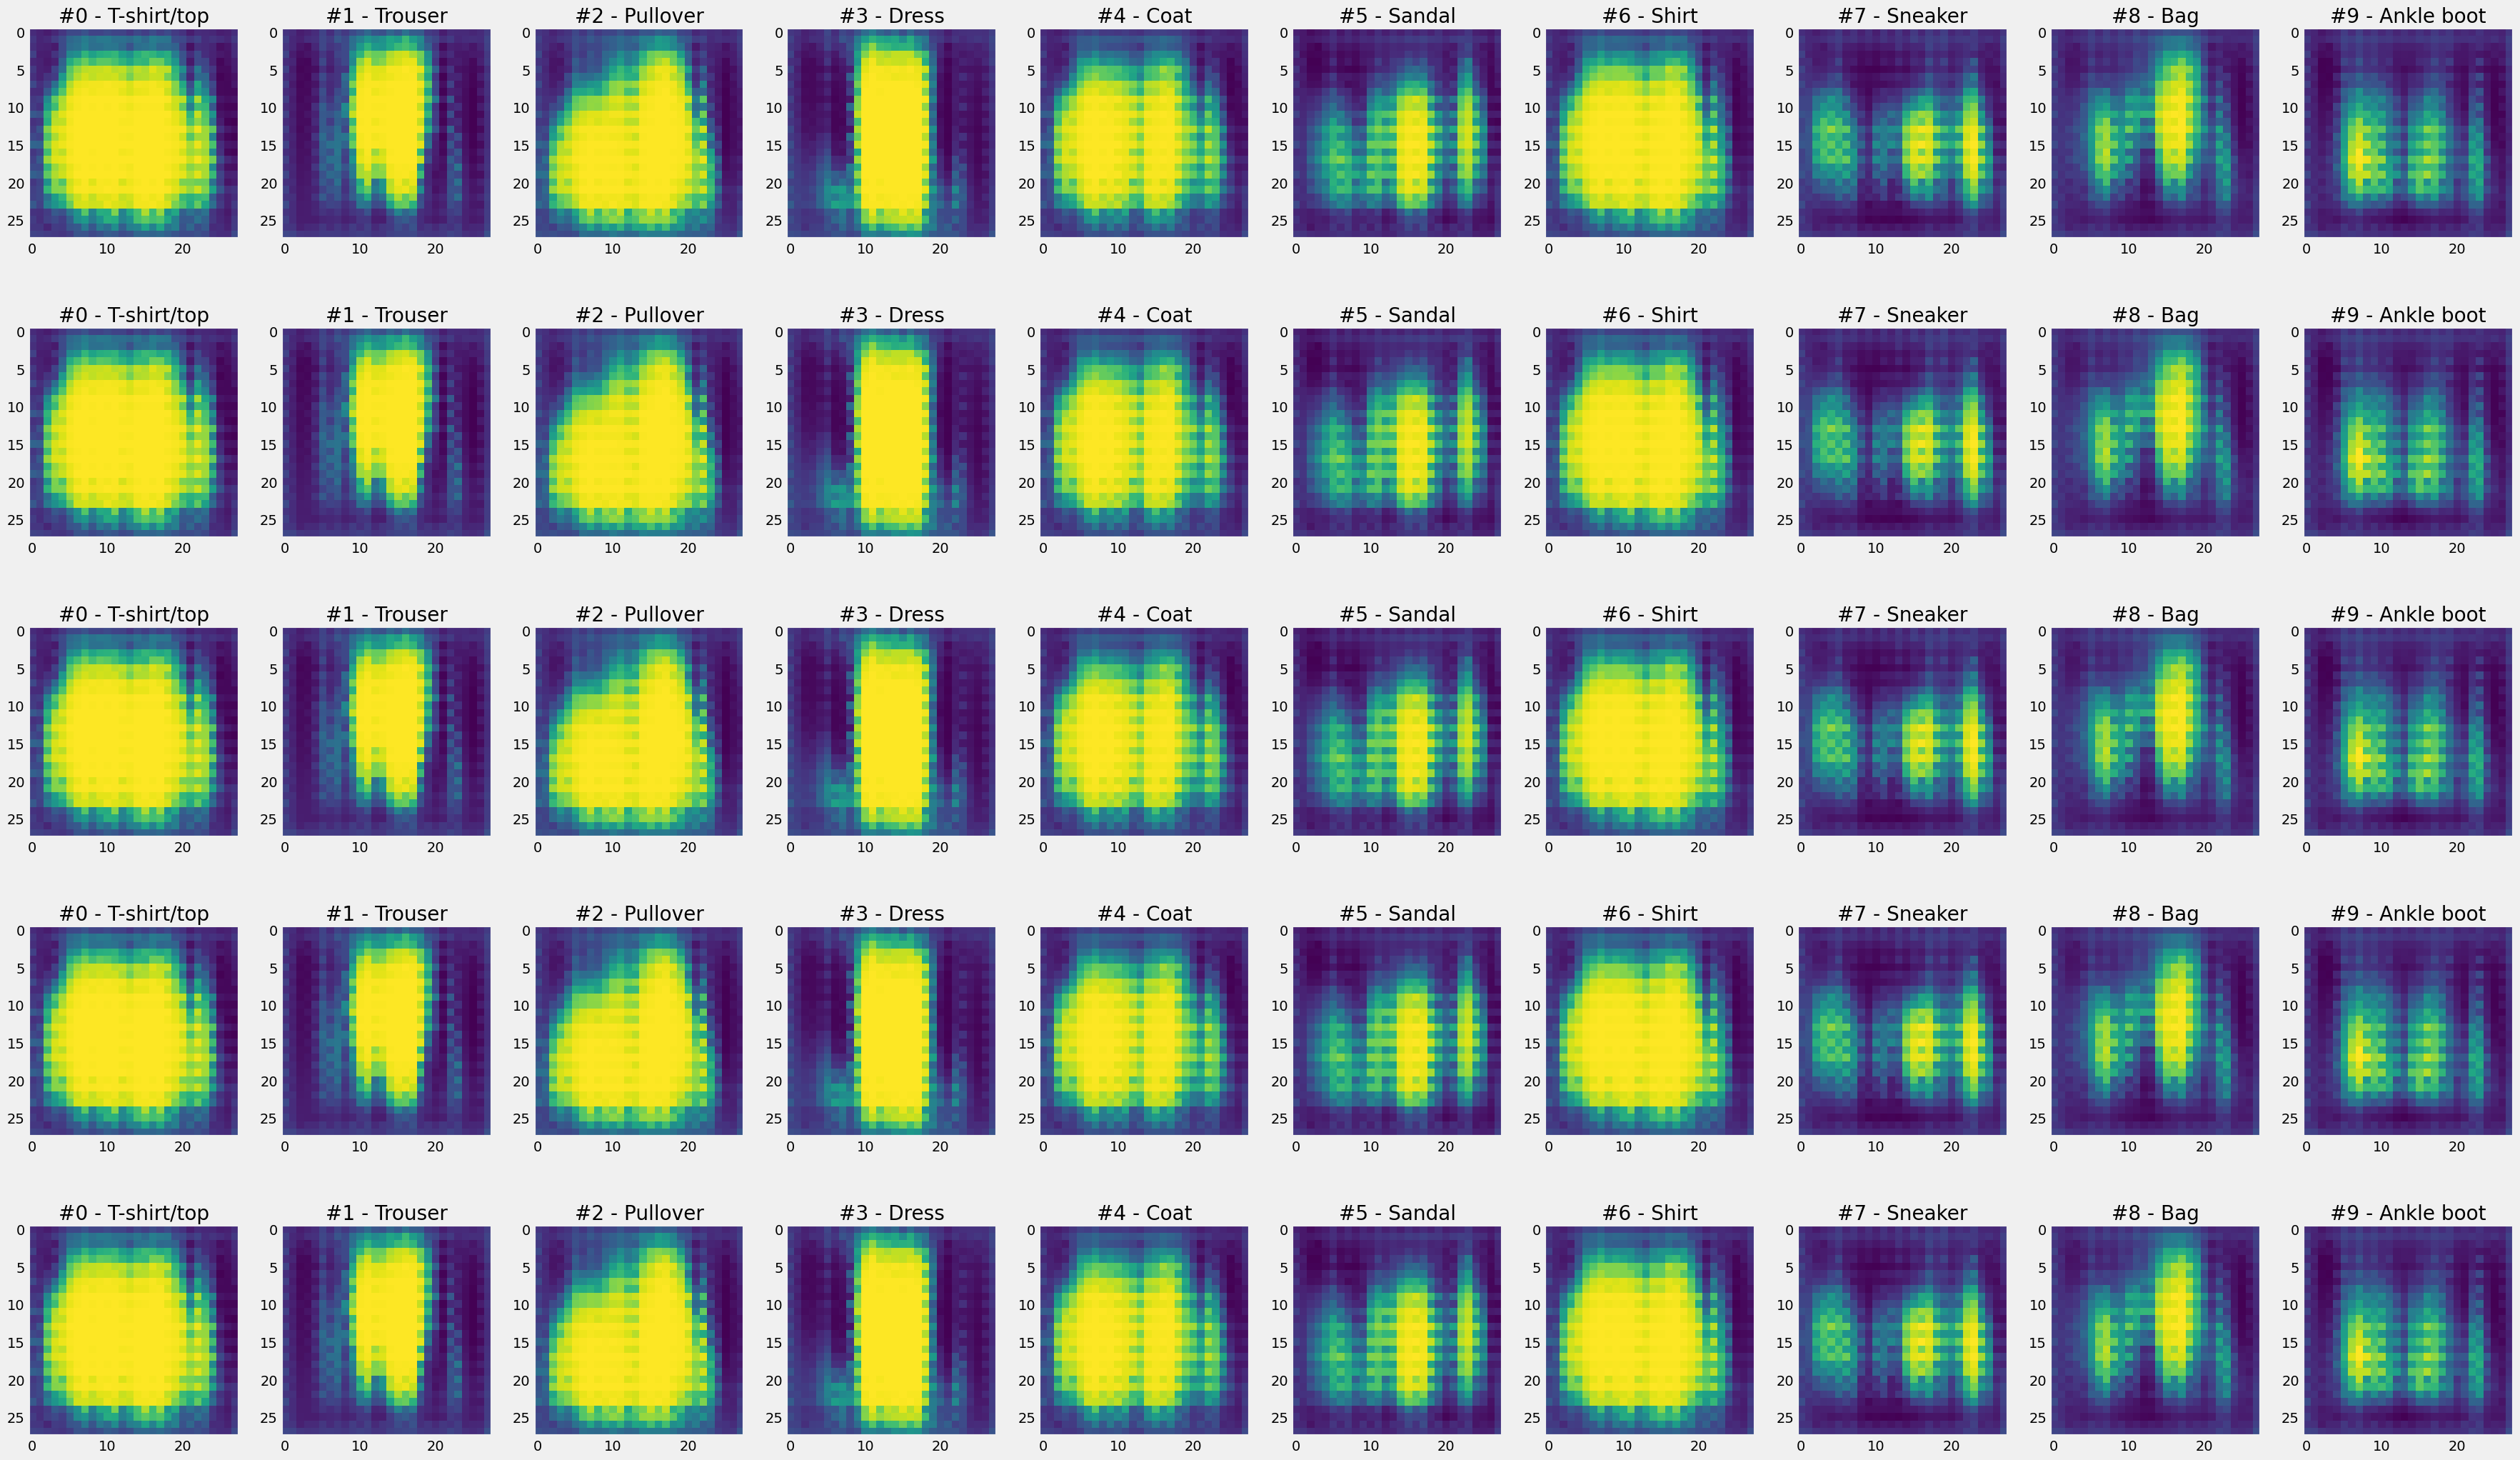

In [112]:
draw_imgs_gan(model, 5, 10, target_classes=torch.arange(10)[None, :].repeat(5, 1).reshape(-1))

## 3. Conditional Diffusion

### 3.1 Forward process (diffusion)

In [113]:
T: int = 50 # Число шагов диффузионного процесса

betas = torch.linspace(1e-4, 1e-1, T)  # \beta_t
alphas = 1 - betas  # \alpha_t
alpha_bars = torch.Tensor(np.cumprod(alphas))  # \bar\alpha_t
sigmas = torch.sqrt(betas)  # \sigma_t


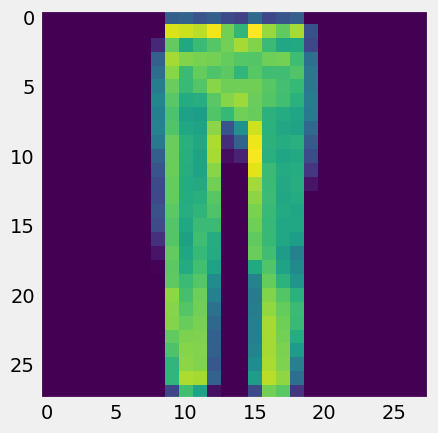

In [119]:
# Берём одну картинку (для примера)
imgs, _ = next(iter(train_loader))
x_0 = imgs[3]

plt.imshow(de_normalize(x_0, True))
plt.grid()
plt.show()


In [120]:
# Сэмплим шум из стандартного нормального распределения
# => \epsilon_0 ~ N(0, I)
epsilon_0 = torch.randn(x_0.shape)


In [121]:
# Добавляем шум к изображению
# => q(x_1 | x_0) = N(x_1; \sqrt(1 - \beta_1) * x_0, \beta_1 * I)
beta_1 = 0.01
x_1 = np.sqrt(1 - beta_1) * x_0 + np.sqrt(beta_1) * epsilon_0


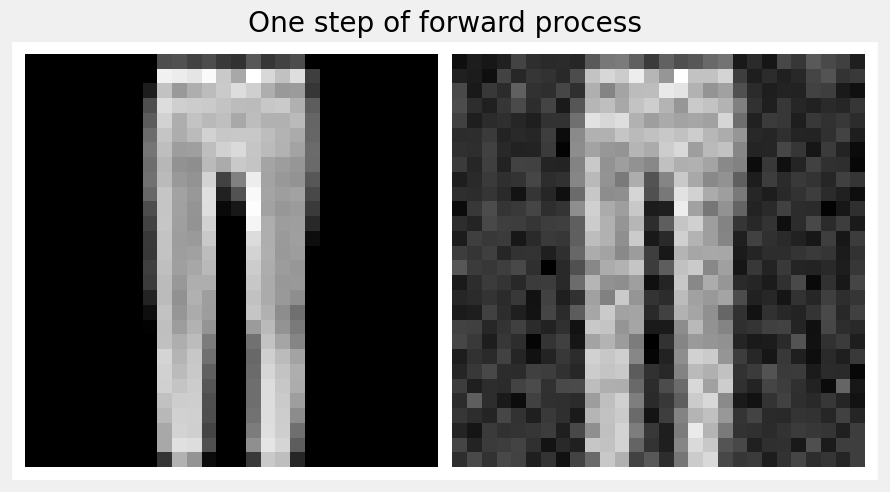

In [122]:
from typing import List
from torchvision.utils import make_grid

# Функция, чтобы выводить картинки в сетке
def show_grid(imgs: List[np.ndarray], title=""):
    fig, ax = plt.subplots(figsize=(10, 10))
    imgs = [ (img - img.min()) / (img.max() - img.min()) for img in imgs ] # Нормализуем в [0, 1]
    img = make_grid(imgs, padding=1, pad_value=1).numpy()
    plt.title(title)
    plt.imshow(np.transpose(img, (1, 2, 0)), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.grid()
    plt.show()

show_grid([x_0, x_1], title=f"One step of forward process")


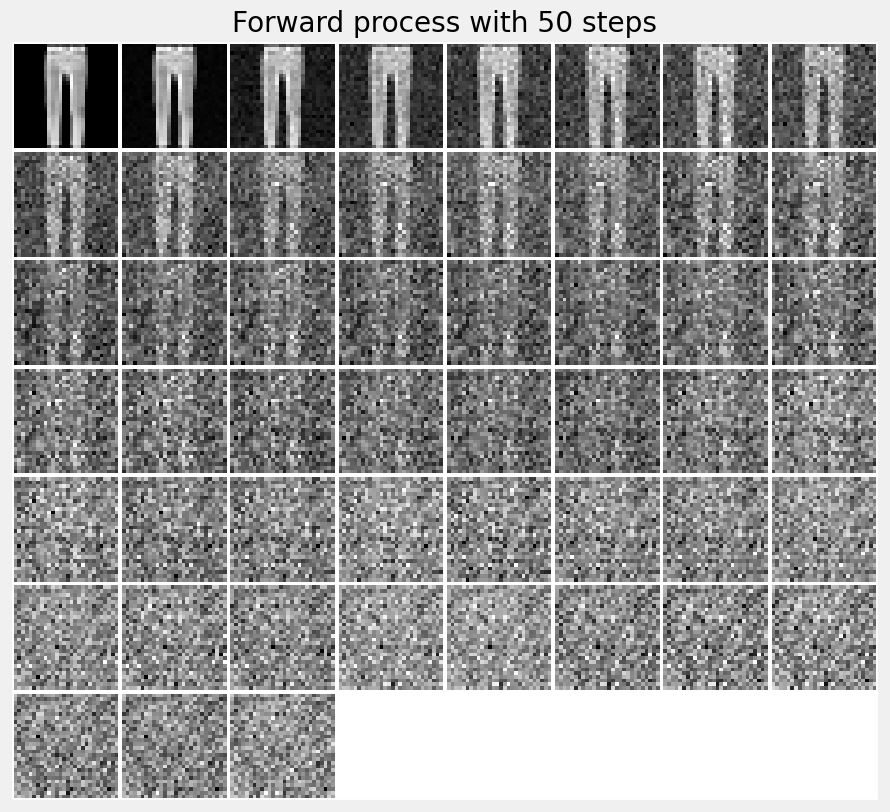

In [123]:
# Forward process
x_ts = []
x_t_1 = x_0
for t in range(T):
    # => \epsilon ~ N(0, I)
    epsilon = torch.randn(x_0.shape)
    # => beta_t
    beta_t = betas[t]
    # => q(x_t | x_t_1) = N(x_t; sqrt(1 - beta_t) * x_t_1, beta_t * I)
    x_t = x_t_1 * np.sqrt(1 - beta_t) + epsilon * np.sqrt(beta_t)
    # Продолжаем сэмплирование
    x_ts.append(x_t)
    x_t_1 = x_t

# Посмотрим на прямой процесс
show_grid([x_0] + x_ts, title=f"Forward process with {T} steps")


### 3.2 Inverse process (denoising)

In [124]:
# Нужные вещи из прямого процесса
# x_1 = x_1
# epsilon_0 = epsilon_0
alpha_1 = 1 - beta_1
alpha_bar_1 = alpha_1
sigma_1 = np.sqrt(beta_1)
z_1 = torch.zeros_like(x_0)


In [125]:
def perfect_diffusion_model(x_t, t, true_epsilon, error_scale = 0):
    return true_epsilon + error_scale * torch.randn(x_t.shape)

# Что если бы у нас был доступ к правильному \epsilon
epsilon_theta = perfect_diffusion_model(x_1, 1, epsilon_0, error_scale=0)


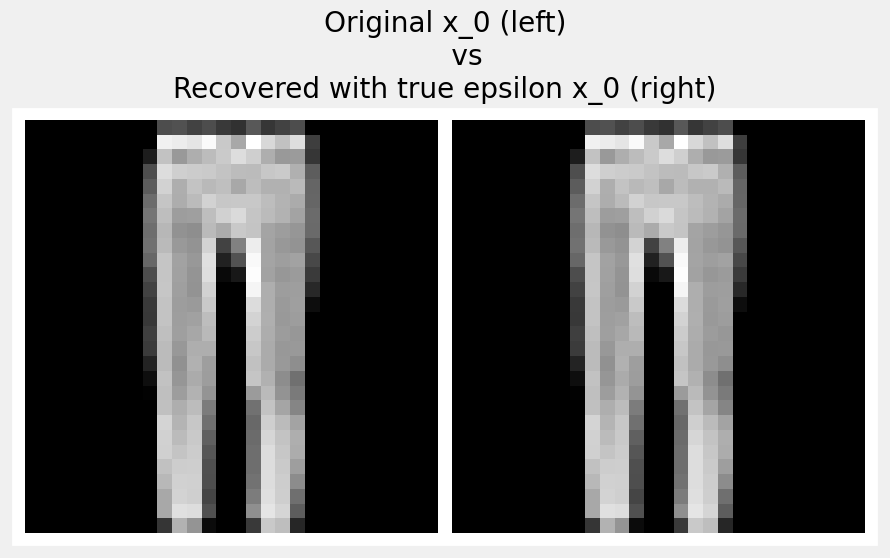

In [126]:
# Inverse process
x_0_hat = 1 / np.sqrt(alpha_1) * (x_1 - (1 - alpha_1) / np.sqrt(1 - alpha_bar_1) * epsilon_theta) + sigma_1 * z_1

show_grid([x_0, x_0_hat], title="Original x_0 (left)\n     vs\nRecovered with true epsilon x_0 (right)")

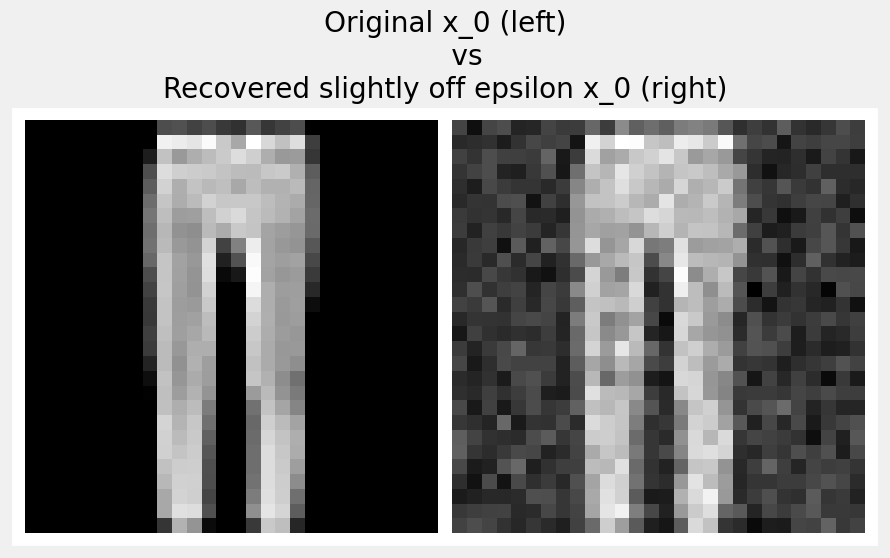

In [127]:
# А теперь что будет если \epsilon будет с небольшой ошибкой
epsilon_theta = perfect_diffusion_model(x_1, 1, epsilon_0, error_scale=1)

# Inverse process
x_0_hat = 1 / np.sqrt(alpha_1) * (x_1 - (1 - alpha_1) / np.sqrt(1 - alpha_bar_1) * epsilon_theta) + sigma_1 * z_1

show_grid([x_0, x_0_hat], title="Original x_0 (left)\n     vs\nRecovered slightly off epsilon x_0 (right)")


### 3.3 Conditional Diffusion class

In [128]:
import math

def get_timestep_embedding(timesteps, embedding_dim):
    """
    This matches the implementation in Denoising Diffusion Probabilistic Models:
    From Fairseq.
    Build sinusoidal embeddings.
    This matches the implementation in tensor2tensor, but differs slightly
    from the description in Section 3.5 of "Attention Is All You Need".
    """
    assert len(timesteps.shape) == 1

    half_dim = embedding_dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, dtype=torch.float32) * -emb)
    emb = emb.to(device=timesteps.device)
    emb = timesteps.float()[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:  # паддим
        emb = torch.nn.functional.pad(emb, (0, 1, 0, 0))
    return emb


In [129]:
get_timestep_embedding(torch.arange(3), 100).shape


torch.Size([3, 100])

In [130]:
class CondDiffusion(nn.Module):
    def __init__(self, t_emb_size, denoiser_params):
        super(CondDiffusion, self).__init__()
        
        self.t_emb_size = t_emb_size
        self.denoiser_params = denoiser_params
        
        self.denoiser = Decoder(
            **denoiser_params,
        )
        
    def forward(self, x, t, c=None):
        t_emb = get_timestep_embedding(t, self.t_emb_size)
        
        return self.denoiser(torch.cat((x, t_emb[:, :, None, None]), dim=1), c)
    

### 3.4 Train cycle

In [154]:
def train_diff(
    model,
    opt,
    loader,
    diff_config,
):
    model.train()
    losses_tr = []
    for imgs, classes in tqdm(loader):
        x_0 = imgs.to(device)  # (наш x_0) bs x c x h x w
        classes = classes.to(device)  # bs

        opt.zero_grad()

        # Сэмплируем t ~ U(0, T)
        t = torch.randint(0, diff_config['T'], (imgs.shape[0],))
        # Сэмплируем \epsilon ~ N(0, I)
        epsilon = torch.randn(x_0.shape, device=model.device)  # bs x c x h x w
        # Сэмплируем x_t ~ q(x_t | x_0) = \sqrt(\bar\alpha) x_0 + \sqrt(1 - \bar\alpha) \epsilon
        x_0_coef = torch.sqrt(diff_config['alpha_bars'][t]).reshape(-1, 1, 1, 1).to(model.device)
        epsilon_coef = torch.sqrt(1 - diff_config['alpha_bars'][t]).reshape(-1, 1, 1, 1).to(model.device)
        x_t = x_0_coef * x_0 + epsilon_coef * epsilon  # bs x c x h x w
        # Предсказываем \epsilon_\theta = f(x_t, t) с помощью нашей нейросети
        epsilon_theta = model(x_t, t.to(model.device), classes)
        # Считаем лосс
        loss = torch.sum((epsilon - epsilon_theta)**2)

        loss.backward()
        opt.step()
        losses_tr.append(loss.item())
    
    return model, opt, np.mean(losses_tr)


def val_diff(model, loader, diff_config):
    model.eval()
    losses_val = []
    with torch.no_grad():
        for imgs, classes in tqdm(loader):
            x_0 = imgs.to(device)  # (наш x_0) bs x c x h x w
            classes = classes.to(device)  # bs

            opt.zero_grad()

            # Сэмплируем t ~ U(0, T)
            t = torch.randint(0, diff_config['T'], (imgs.shape[0],))
            # Сэмплируем \epsilon ~ N(0, I)
            epsilon = torch.randn(x_0.shape, device=model.device)  # bs x c x h x w
            # Сэмплируем x_t ~ q(x_t | x_0) = \sqrt(\bar\alpha) x_0 + \sqrt(1 - \bar\alpha) \epsilon
            x_0_coef = torch.sqrt(diff_config['alpha_bars'][t]).reshape(-1, 1, 1, 1).to(model.device)
            epsilon_coef = torch.sqrt(1 - diff_config['alpha_bars'][t]).reshape(-1, 1, 1, 1).to(model.device)
            x_t = x_0_coef * x_0 + epsilon_coef * epsilon  # bs x c x h x w
            # Предсказываем \epsilon_\theta = f(x_t, t) с помощью нашей нейросети
            epsilon_theta = model(x_t, t.to(model.device), classes)
            # Считаем лосс
            loss = torch.sum((epsilon - epsilon_theta)**2)

            loss.backward()
            opt.step()
            losses_val.append(loss.item())
    return np.mean(losses_val)


In [155]:
def learning_loop_diff(
    model,
    optimizer,
    train_loader,
    val_loader,
    T = 50, # число шагов диффузии
    betas = torch.linspace(1e-4, 1e-1, 50),  # схема диффузии
    scheduler=None,
    min_lr=None,
    epochs=10,
    val_every=1,
    draw_every=1,
    model_name=None,
    chkp_folder="./chkps",
    num_classes=0,
    plots=None,
    starting_epoch=0,
):
    model_name = get_model_name(chkp_folder, model_name)
    
    if plots is None:
        plots = {
            'train': [],
            'val': [],
            "lr": [],
        }

    # Переданные важные параметры диффузионного процесса
    diff_config = dict(
        T = T,
        betas = betas,
        alphas = 1 - betas,
        sigmas = torch.sqrt(betas),
    )
    diff_config['alpha_bars'] = torch.Tensor(np.cumprod(diff_config['alphas']))
    
    for epoch in np.arange(1, epochs+1) + starting_epoch:
        print(f'#{epoch}/{epochs}:')

        plots['lr'].append(get_lr(optimizer))
        
        model, optimizer, train_loss = train_diff(model, optimizer, train_loader, diff_config)
        plots['train'].extend(train_loss)

        if not (epoch % val_every):
            print("validate")
            val_loss = val_diff(model, val_loader, diff_config)
            plots['val'].append(val_loss)
            
            # Сохраняем модель
            if not os.path.exists(chkp_folder):
                os.makedirs(chkp_folder)
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'plots': plots,
                    'diff_config': diff_config,
                },
                os.path.join(chkp_folder, model_name + '.pt'),
            )
            
            # Шедулинг
            if scheduler:
                try:
                    scheduler.step()
                except:
                    scheduler.step(val_loss)

        if not (epoch % draw_every):
            clear_output(True)
            
            ww = 2
            fig, ax = plt.subplots(1, ww, figsize=(25, 12))
            fig.suptitle(f'#{epoch}/{epochs}:')

            plt.subplot(1, ww, 1)
            plt.title('losses')
            plt.plot(plots['train'], 'r.-', label='train', alpha=0.7)
            plt.plot(plots['val'], 'g.-', label='val', alpha=0.7)
            plt.legend()
            
            plt.subplot(1, ww, 2)
            plt.title('learning rates')
            plt.plot(plots["lr"], 'b.-', label='lr', alpha=0.7)
            plt.legend()
            
            plt.show()
                
        
        if min_lr and get_lr(optimizer) <= min_lr:
            print(f'Learning process ended with early stop after epoch {epoch}')
            break
    
    return model, optimizer_d, optimizer_g, plots

### 3.5 Inference

In [136]:
def inference(model, n_samples: int, T: int, alphas, alpha_bars, sigmas, seed: int = 1):
    '''Generate images from diffusion model.'''
    model.eval()
    torch.manual_seed(seed)
    with torch.no_grad():
        # Dimensions
        n_channels: int = 1 # 1 for grayscale
        H, W = 28, 28 # 28 pixels
        # x_T \sim N(0, I)
        x_T = torch.randn((n_samples, n_channels, H, W))
        # For t = T ... 1
        x_t = x_T
        x_ts = [] # save image as diffusion occurs
        for t in tqdm(range(T-1, -1, -1)):
            # z \sim N(0, I) if t > 1 else z = 0
            z = torch.randn(x_t.shape) if t > 1 else torch.zeros_like(x_t)
            # Setup terms for x_t-1
            t_vector = torch.fill(torch.zeros((n_samples,)), t)
            epsilon_theta = model(x_t.to(model.device), t_vector.to(model.device), class_).to('cpu')
            # x_t-1 = (1 / sqrt(alpha_t)) * (x_t - (1 - alpha_t) / (sqrt(1 - alpha_bar_t)) * epsilon_theta(x_t, t)) + sigma_t * z
            x_t_1  = (
                1 / torch.sqrt(alphas[t]) * (x_t - (1 - alphas[t]) / torch.sqrt(1 - alpha_bars[t]) * epsilon_theta)
                + sigmas[t] * z
            )
            x_ts.append(x_t)
            x_t = x_t_1
    return torch.stack(x_ts).transpose(0, 1)